In [ ]:
#set Plotting configuration
!pip install SciencePlots
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

# Analytical current profile check

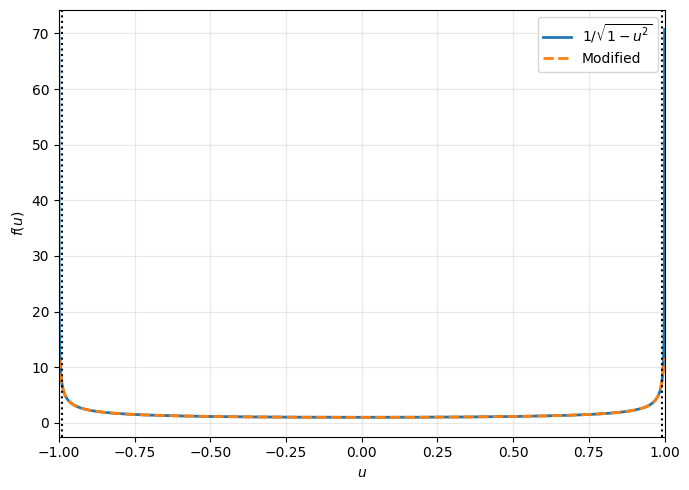

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
lam_tilde = 0.01

u = np.linspace(-0.9999, 0.9999, 3000)

# Original profile
pure = 1/np.sqrt(1-u**2)

# Modified profile
modified = np.empty_like(u)

center = np.abs(u) <= (1-lam_tilde)
edge = ~center

# EXACTLY the same as the original in the center
modified[center] = pure[center]

# Exponential edge
modified[edge] = (
    1/np.sqrt(2*lam_tilde)
    * np.exp(-((1-lam_tilde)-np.abs(u[edge]))/(2*lam_tilde))
)

plt.figure(figsize=(7,5))
plt.plot(u, pure, lw=2, label=r"$1/\sqrt{1-u^2}$")
plt.plot(u, modified, '--', lw=2, label="Modified")

plt.axvline(1-lam_tilde, ls=':', color='k')
plt.axvline(-(1-lam_tilde), ls=':', color='k')

#plt.yscale('log')
plt.xlim(-1,1)
#plt.ylim(0,8)
plt.xlabel(r"$u$")
plt.ylabel(r"$f(u)$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Series convergence check

This is the series of Bessel fucntions that comes in the Fourier transform result.

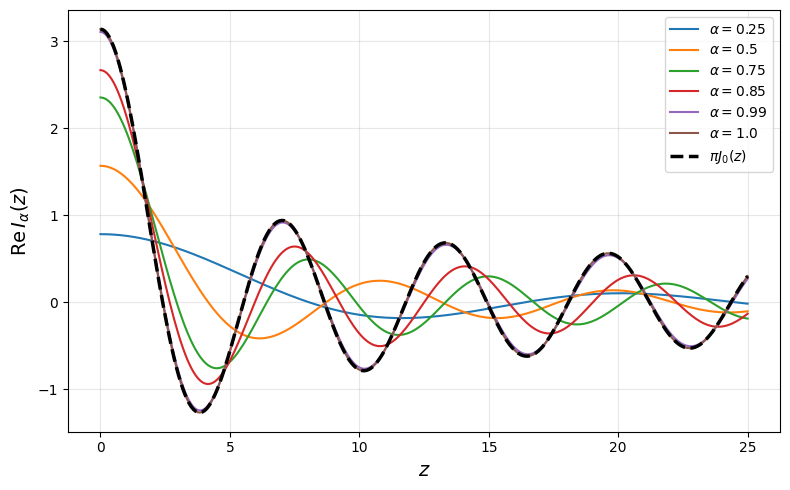

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import j0

# Range of z
z_vals = np.linspace(0, 25, 300)

# Values of alpha to compare
alphas = [0.25, 0.5, 0.75, 0.85, 0.99, 1.0]

# Compute integral
def I_alpha(z, alpha):
    a = alpha*np.pi/2

    real = quad(lambda th: np.cos(z*np.sin(th)), -a, a, limit=300)[0]
    imag = quad(lambda th: np.sin(z*np.sin(th)), -a, a, limit=300)[0]

    return real + 1j*imag

# Compute curves
results = {}
for alpha in alphas:
    results[alpha] = np.array([I_alpha(z, alpha) for z in z_vals])

# Plot real part
plt.figure(figsize=(8,5))

for alpha in alphas:
    plt.plot(z_vals,
             results[alpha].real,
             label=fr"$\alpha={alpha}$")

plt.plot(z_vals,
         np.pi*j0(z_vals),
         'k--',
         lw=2.5,
         label=r"$\pi J_0(z)$")

plt.xlabel(r"$z$", fontsize=14)
plt.ylabel(r"$\mathrm{Re}\,I_\alpha(z)$", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

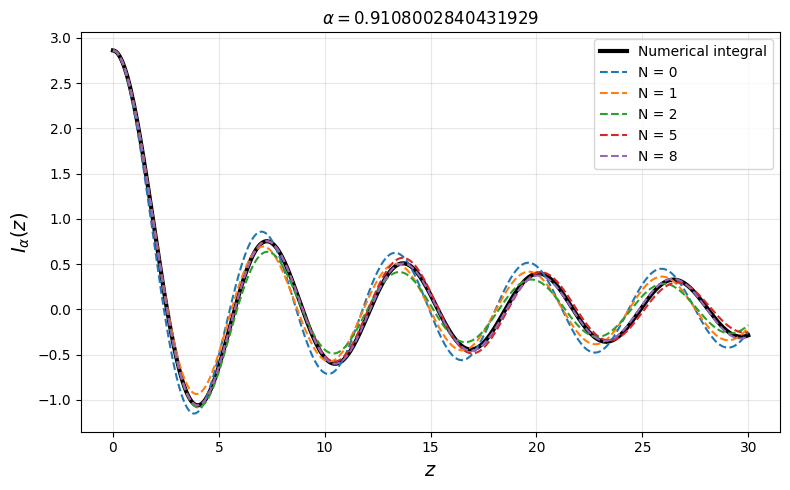

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import jv

# ----------------------------
# Parameters
# ----------------------------
alpha = 0.9108002840431929          # Change this
z = np.linspace(0, 30, 400)

# Number of Bessel terms to display
Ns = [0, 1, 2, 5,8]

# ----------------------------
# Numerical integral
# ----------------------------
a = alpha*np.pi/2

def I_numeric(z):
    val, _ = quad(
        lambda th: np.cos(z*np.sin(th)),
        -a, a,
        epsabs=1e-12,
        epsrel=1e-12,
        limit=500
    )
    return val

I_num = np.array([I_numeric(zz) for zz in z])

# ----------------------------
# Series approximation
# ----------------------------
def I_series(z, alpha, N):
    s = alpha*np.pi*jv(0, z)

    for n in range(1, N+1):
        coeff = 2*np.sin(np.pi*n*alpha)/n
        s += coeff*jv(2*n, z)

    return s

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8,5))

plt.plot(z, I_num, 'k', lw=3, label='Numerical integral')

for N in Ns:
    plt.plot(
        z,
        I_series(z, alpha, N),
        '--',
        label=f'N = {N}'
    )

plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$I_\alpha(z)$', fontsize=14)
plt.title(fr'$\alpha={alpha}$')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

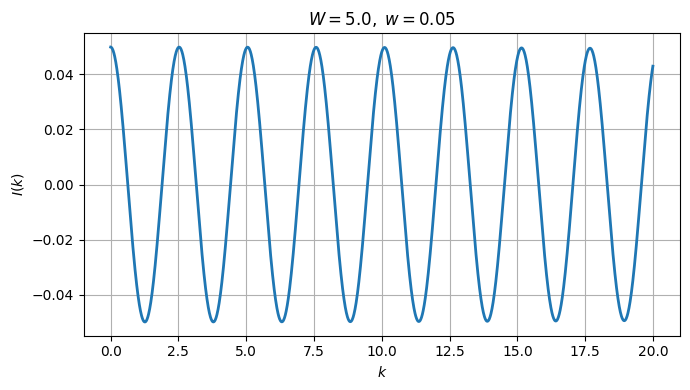

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
W = 5.0
w = 0.01 * W

# k values
k = np.linspace(0, 20, 2000)

# Compute the integral
den = k**2 + 1/W**2

I = 2 * (
    np.exp(-w/(2*W)) * (
        k * np.sin(k*W/2)
        - (1/W) * np.cos(k*W/2)
    )
    - (
        k * np.sin(k*(W-w)/2)
        - (1/W) * np.cos(k*(W-w)/2)
    )
) / den

# Plot
plt.figure(figsize=(7,4))
plt.plot(k, I, lw=2)
plt.xlabel(r"$k$")
plt.ylabel(r"$I(k)$")
plt.title(fr"$W={W},\; w={w}$")
plt.grid(True)
plt.tight_layout()
plt.show()

peak |B(k)| at k = 0.0000
k_c (1/e of peak)      ~ 1.1542
k_c (half-max)         ~ 0.8854
k_c (rms, energy-weighted) ~ 0.6876
naive estimate min(1/Z, 1/W) = 0.5000

--> using k_c = 1.1542
--> tau_D = 1/(D k_c^2) = 0.7506  (in units where D=1: t)

Saved plot to Bk_analysis.png


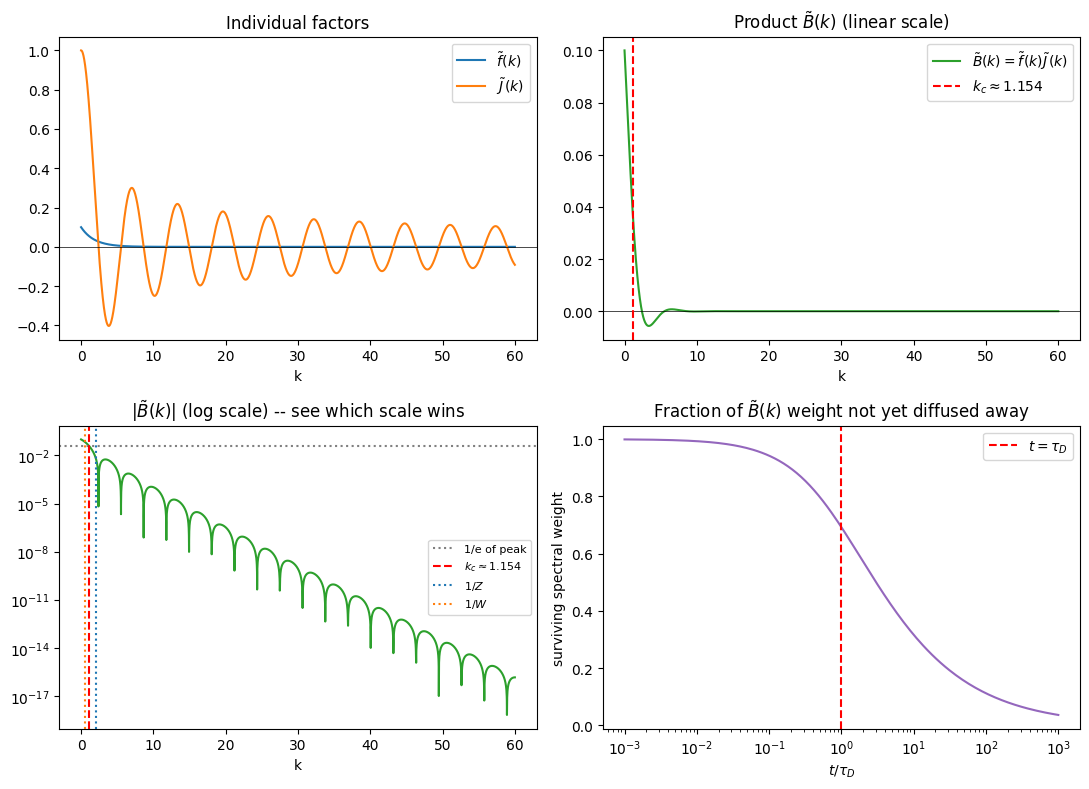

In [ ]:
import numpy as np
from scipy.special import j0
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Parameters -- EDIT THESE to your actual values
# ----------------------------------------------------------------------
Z = 5e-1    # depth / decay parameter in f_tilde  [same units as 1/k]  -- NOW SMALL
b = 0.1      # "slab thickness" parameter in f_tilde
W = 2.0      # width parameter in J_tilde
C = 1.0      # constant prefactor in J_tilde
D = 1.0      # diffusion coefficient (only needed to get tau_D at the end)

# ----------------------------------------------------------------------
# Definitions
# ----------------------------------------------------------------------
def f_tilde(k, Z=Z, b=b):
    """f_tilde(k) = e^{-Z|k|} (1 - e^{-b|k|}) / |k|, with the k->0 limit = b."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk)
    small = absk < 1e-13
    out[~small] = np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / absk[~small]
    out[small] = b  # analytic k->0 limit
    return out

def J_tilde(k, C=C, W=W):
    """J_tilde(k) = (C W / 2) * J0(k W / 2)"""
    k = np.asarray(k, dtype=float)
    return (C * W / 2.0) * j0(k * W / 2.0)

def B_tilde(k, Z=Z, b=b, C=C, W=W):
    return f_tilde(k, Z, b) * J_tilde(k, C, W)

# ----------------------------------------------------------------------
# k-grid (only need k>0 since everything here is even in k)
# ----------------------------------------------------------------------
k = np.linspace(1e-6, 30/max(Z, b, 1e-6, 1/W), 4000)
# make sure we also resolve the 1/W envelope scale well:
k = np.union1d(k, np.linspace(1e-6, 30.0/W, 4000))
k = np.sort(k)

Bk   = B_tilde(k)
fk   = f_tilde(k)
Jk   = J_tilde(k)
absB = np.abs(Bk)

# ----------------------------------------------------------------------
# Extract a characteristic k_c a few different (complementary) ways
# ----------------------------------------------------------------------

# (1) "1/e of peak" width of |B_tilde(k)|
peak = absB.max()
target = peak / np.e
# find first crossing after the peak
i_peak = np.argmax(absB)
k_1e = None
for i in range(i_peak, len(k)-1):
    if absB[i] >= target >= absB[i+1]:
        # linear interpolation
        k_1e = k[i] + (target - absB[i]) * (k[i+1]-k[i]) / (absB[i+1]-absB[i])
        break

# (2) second-moment ("rms") width:  k_rms^2 = int k^2 |B|^2 dk / int |B|^2 dk
w = absB**2
k_rms = np.sqrt(np.trapezoid(k**2 * w, k) / np.trapezoid(w, k))

# (3) half-max width
half = peak/2
k_half = None
for i in range(i_peak, len(k)-1):
    if absB[i] >= half >= absB[i+1]:
        k_half = k[i] + (half - absB[i]) * (k[i+1]-k[i]) / (absB[i+1]-absB[i])
        break

print(f"peak |B(k)| at k = {k[i_peak]:.4f}")
print(f"k_c (1/e of peak)      ~ {k_1e:.4f}")
print(f"k_c (half-max)         ~ {k_half:.4f}")
print(f"k_c (rms, energy-weighted) ~ {k_rms:.4f}")
print(f"naive estimate min(1/Z, 1/W) = {min(1/Z, 1/W):.4f}")

k_c = k_1e  # pick your preferred definition
tau_D = 1.0 / (D * k_c**2)
print(f"\n--> using k_c = {k_c:.4f}")
print(f"--> tau_D = 1/(D k_c^2) = {tau_D:.4f}  (in units where D=1: t)")

# ----------------------------------------------------------------------
# Plots
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0,0]
ax.plot(k, fk, label=r'$\tilde f(k)$', color='tab:blue')
ax.plot(k, Jk, label=r'$\tilde J(k)$', color='tab:orange')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('k')
ax.set_title('Individual factors')
ax.legend()

ax = axes[0,1]
ax.plot(k, Bk, color='tab:green', label=r'$\tilde B(k)=\tilde f(k)\tilde J(k)$')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(k_c, color='red', ls='--', label=fr'$k_c\approx{k_c:.3f}$')
ax.set_xlabel('k')
ax.set_title(r'Product $\tilde B(k)$ (linear scale)')
ax.legend()

ax = axes[1,0]
ax.semilogy(k, np.abs(Bk)+1e-300, color='tab:green')
ax.axhline(peak/np.e, color='gray', ls=':', label='1/e of peak')
ax.axvline(k_c, color='red', ls='--', label=fr'$k_c\approx{k_c:.3f}$')
ax.axvline(1/Z, color='tab:blue', ls=':', label=r'$1/Z$')
ax.axvline(1/W, color='tab:orange', ls=':', label=r'$1/W$')
ax.set_xlabel('k')
ax.set_title(r'$|\tilde B(k)|$ (log scale) -- see which scale wins')
ax.legend(fontsize=8)

# low-pass filtered fraction vs t: shows how much of B(k)'s "weight" survives
t_vals = np.logspace(-3, 3, 200) * tau_D
weight0 = np.trapezoid(np.abs(Bk)**2, k)
surv = []
for t in t_vals:
    filt = np.exp(-k**2 * D * t)
    surv.append(np.trapezoid(np.abs(Bk*filt)**2, k) / weight0)
surv = np.array(surv)

ax = axes[1,1]
ax.semilogx(t_vals/tau_D, surv, color='tab:purple')
ax.axvline(1.0, color='red', ls='--', label=r'$t=\tau_D$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel('surviving spectral weight')
ax.set_title(r'Fraction of $\tilde B(k)$ weight not yet diffused away')
ax.legend()

plt.tight_layout()
plt.savefig('Bk_analysis.png', dpi=150)
print("\nSaved plot to Bk_analysis.png")

# Solving Diffusion equation

max |Im B(x)| / max |Re B(x)| = 6.358880262724798e-17
k_c ~ 1.6393,  tau_D ~ 0.3721
Saved plot to m_xt.png
Saved plot to small_t_check.png


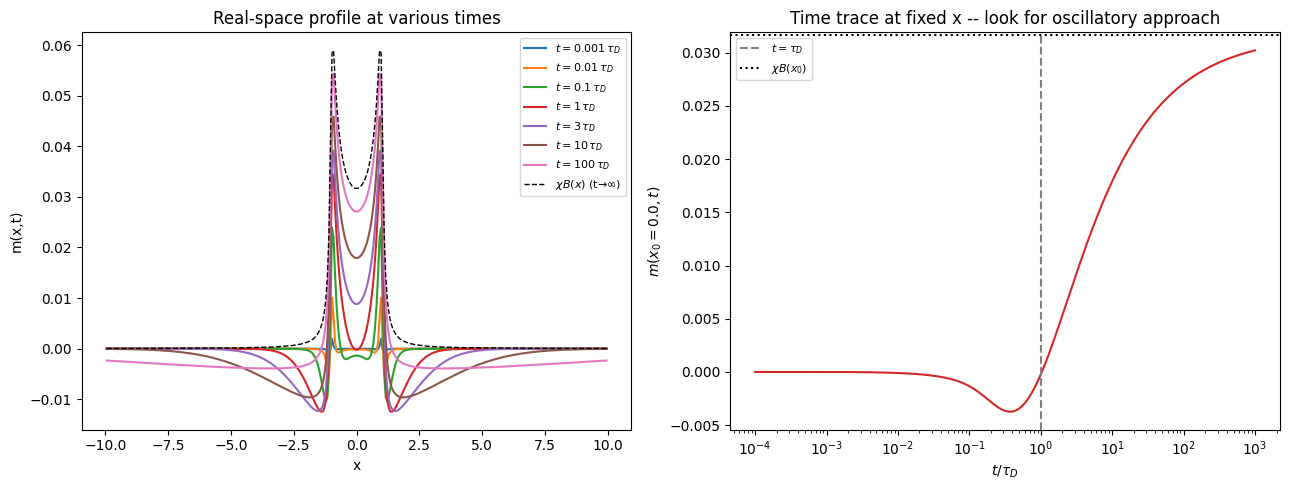

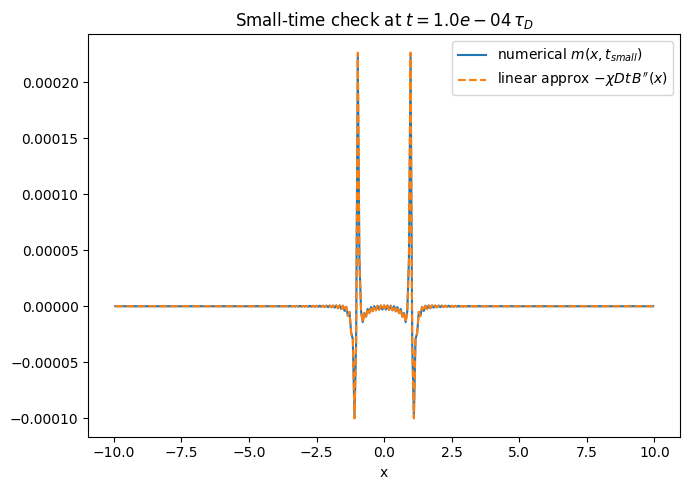

In [ ]:
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Parameters -- EDIT THESE to your actual values
# ----------------------------------------------------------------------
Z = 0.05     # depth / decay parameter in f_tilde
b = 0.1      # "slab thickness" parameter in f_tilde
W = 2.0      # width parameter in J_tilde
C = 1.0      # constant prefactor in J_tilde
D = 1.0      # diffusion coefficient
chi = 1.0    # susceptibility prefactor

# ----------------------------------------------------------------------
# Definitions (careful k->0 handling, no premature masking)
# ----------------------------------------------------------------------
def f_tilde(k, Z=Z, b=b):
    """f_tilde(k) = e^{-Z|k|} (1 - e^{-b|k|}) / |k|, with the k->0 limit = b."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk)
    small = absk < 1e-13
    out[~small] = np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / absk[~small]
    out[small] = b  # analytic k->0 limit
    return out

def J_tilde(k, C=C, W=W):
    """J_tilde(k) = (C W / 2) * J0(k W / 2)"""
    k = np.asarray(k, dtype=float)
    return (C * W / 2.0) * j0(k * W / 2.0)

def B_tilde(k, Z=Z, b=b, C=C, W=W):
    return f_tilde(k, Z, b) * J_tilde(k, C, W)

# ----------------------------------------------------------------------
# Uniform grid setup for FFT
# ----------------------------------------------------------------------
# Need: (1) fine enough dx to resolve the highest relevant k (Bessel
#           oscillations / exp(-Z k) tail), and (2) large enough box L
#           to resolve the smallest relevant k (k->0 structure) and to
#           avoid periodic wrap-around of B(x) itself.
N = 2**16                 # number of grid points
L = 4000.0                # box size in x -- must be >> W, Z and >> sqrt(D*t_max)
dx = L / N
x = (np.arange(N) - N//2) * dx          # x in [-L/2, L/2)

# FFT frequency convention: numpy's fftfreq gives cycles/sample; convert to
# angular wavenumber k = 2*pi*freq
k = 2*np.pi*np.fft.fftfreq(N, d=dx)     # this k array is in FFT order (0,+,...,-,...)

# Evaluate B_tilde(k) directly on the FFT k-grid (k=0 handled analytically above)
Bk = B_tilde(k)

# ----------------------------------------------------------------------
# Real-space B(x) via inverse FFT (as a check / for the t->infinity limit)
#   Convention used here:  B_tilde(k) = int B(x) e^{-i k x} dx
#                          B(x)       = 1/(2pi) int B_tilde(k) e^{i k x} dk
# With numpy's ifft convention (sum_n a_n e^{+2pi i k n/N}), and our k
# array built from fftfreq*2pi, the correct inversion is:
#   B(x_m) = (1/dx) * ifft( Bk )   -- see derivation notes below
# ----------------------------------------------------------------------
def inverse_transform(Fk):
    """Given F(k) sampled on our fftfreq-based k grid, return F(x) on the x grid."""
    return np.fft.ifft(Fk) / dx

Bx = inverse_transform(Bk)
# Bx should be (numerically) real; check imaginary part is negligible
print("max |Im B(x)| / max |Re B(x)| =",
      np.max(np.abs(Bx.imag)) / np.max(np.abs(Bx.real)))
Bx = Bx.real
Bx = np.fft.fftshift(Bx)   # reorder to match x (which is already monotonic)

# ----------------------------------------------------------------------
# Time-dependent solution:
#   m(x,t) = chi * theta(t) * [ B(x) - IFFT( B_tilde(k) * exp(-k^2 D t) ) ]
# ----------------------------------------------------------------------
def m_of_x_t(t):
    filt = np.exp(-k**2 * D * t)
    diffused = inverse_transform(Bk * filt).real
    diffused = np.fft.fftshift(diffused)
    return chi * (Bx - diffused)

# characteristic tau_D estimated from k_c (1/e criterion), reused from before
absB = np.abs(np.fft.fftshift(Bk))  # not meaningful ordering-wise for k=0 centering; recompute properly
k_sorted_idx = np.argsort(k)
k_sorted = k[k_sorted_idx]
absB_sorted = np.abs(Bk[k_sorted_idx])
peak = absB_sorted.max()
i_peak = np.argmax(absB_sorted)
target = peak/np.e
k_c = None
for i in range(i_peak, len(k_sorted)-1):
    if absB_sorted[i] >= target >= absB_sorted[i+1]:
        k_c = k_sorted[i] + (target-absB_sorted[i])*(k_sorted[i+1]-k_sorted[i])/(absB_sorted[i+1]-absB_sorted[i])
        break
tau_D = 1.0/(D*k_c**2)
print(f"k_c ~ {k_c:.4f},  tau_D ~ {tau_D:.4f}")

# ----------------------------------------------------------------------
# Evaluate m(x,t) at several times spanning well below/above tau_D
# ----------------------------------------------------------------------
t_list = np.array([1e-3, 1e-2, 1e-1, 1, 3, 10, 100]) * tau_D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
xmax_plot = 5*W  # zoom into the physically relevant region
mask_plot = np.abs(x) < xmax_plot
for t in t_list:
    mt = m_of_x_t(t)
    ax.plot(x[mask_plot], mt[mask_plot], label=fr'$t={t/tau_D:.3g}\,\tau_D$')
ax.plot(x[mask_plot], chi*Bx[mask_plot], 'k--', lw=1, label=r'$\chi B(x)$ (t→∞)')
ax.set_xlabel('x')
ax.set_ylabel('m(x,t)')
ax.set_title('Real-space profile at various times')
ax.legend(fontsize=8)

# time trace at a fixed observation point x0
x0 = 0.0
i0 = np.argmin(np.abs(x - x0))
t_trace = np.logspace(-4, 3, 300) * tau_D
m_trace = np.array([m_of_x_t(t)[i0] for t in t_trace])

ax = axes[1]
ax.semilogx(t_trace/tau_D, m_trace, color='tab:red')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.axhline(chi*Bx[i0], color='k', ls=':', label=r'$\chi B(x_0)$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(fr'$m(x_0={x0},t)$')
ax.set_title('Time trace at fixed x -- look for oscillatory approach')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('m_xt.png', dpi=150)
print("Saved plot to m_xt.png")

# ----------------------------------------------------------------------
# Check the small-t linear regime numerically against -chi*D*t*B''(x)
# ----------------------------------------------------------------------
# B''(x) via spectral differentiation: FT of B'' is (ik)^2 B_tilde(k) = -k^2 Bk
Bpp = inverse_transform(-k**2 * Bk).real
Bpp = np.fft.fftshift(Bpp)

t_small = 1e-4 * tau_D
m_num = m_of_x_t(t_small)
m_lin = chi * D * t_small * (-Bpp)

fig2, ax2 = plt.subplots(figsize=(7,5))
ax2.plot(x[mask_plot], m_num[mask_plot], label='numerical $m(x,t_{small})$')
ax2.plot(x[mask_plot], m_lin[mask_plot], '--', label=r"linear approx $-\chi D t\,B''(x)$")
ax2.set_xlabel('x')
ax2.set_title(fr'Small-time check at $t={t_small/tau_D:.1e}\,\tau_D$')
ax2.legend()
plt.tight_layout()
plt.savefig('small_t_check.png', dpi=150)
print("Saved plot to small_t_check.png")

## Flux computation

### x component

max |Im B(x)| / max |Re B(x)| = 5.731139639872419e-17
k_c ~ 1.5297,  tau_D ~ 0.4273
Saved plot to m_xt.png
Saved plot to phi_t.png

Early-time power-law fit over first 40 points (t/tau_D in [1.00e-04, 4.83e-04]):
  phi(t) ~ A * t^p
  p (slope)   = 0.9971   (expect ~1 from linear-in-t theory)
  A           = 7.8238e-02
Saved plot to phi_t_fit.png
Saved plot to small_t_check.png


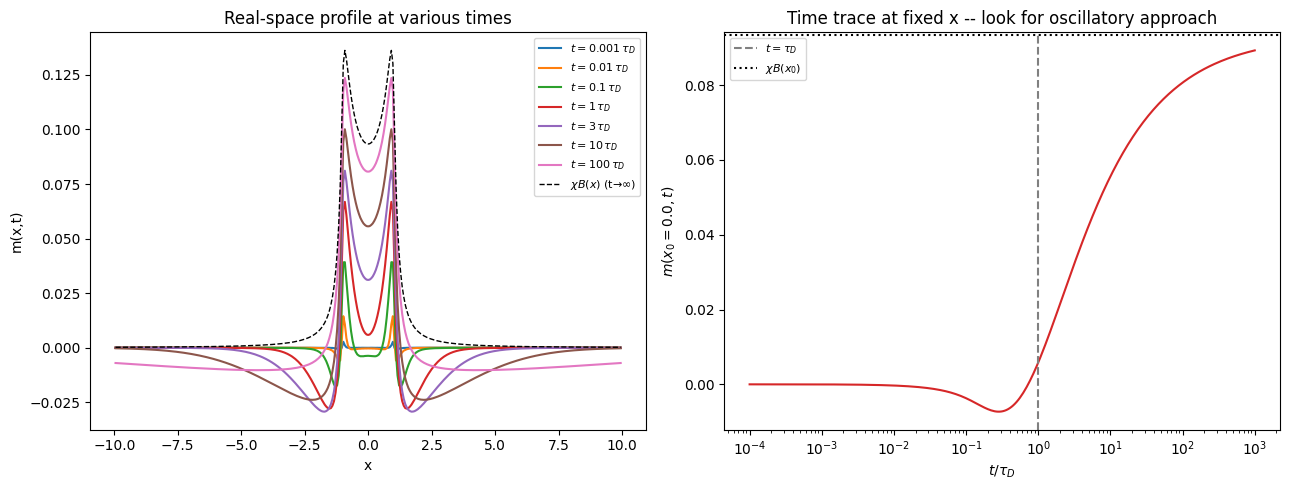

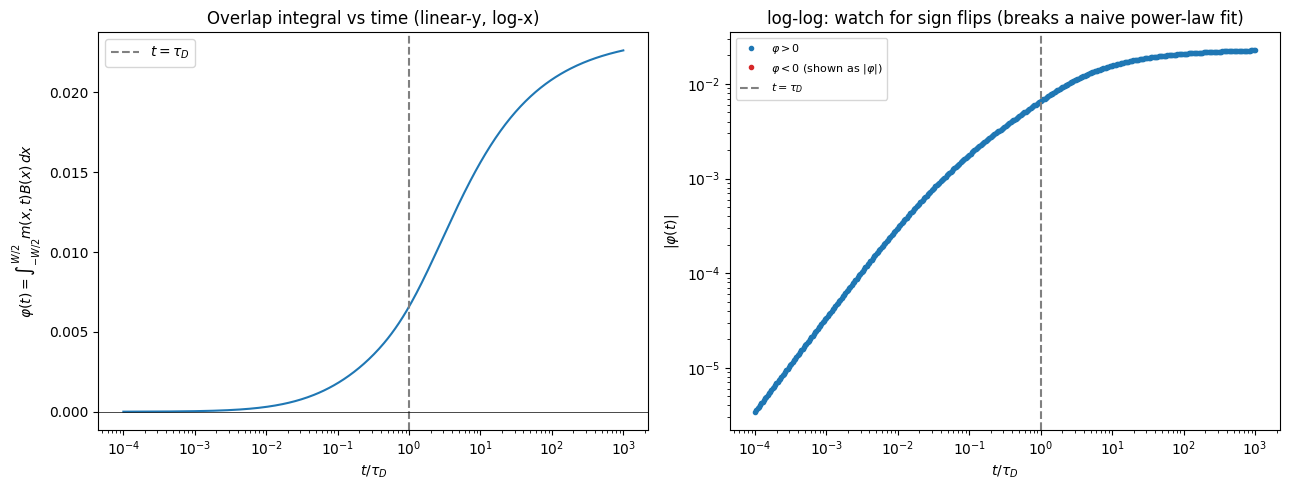

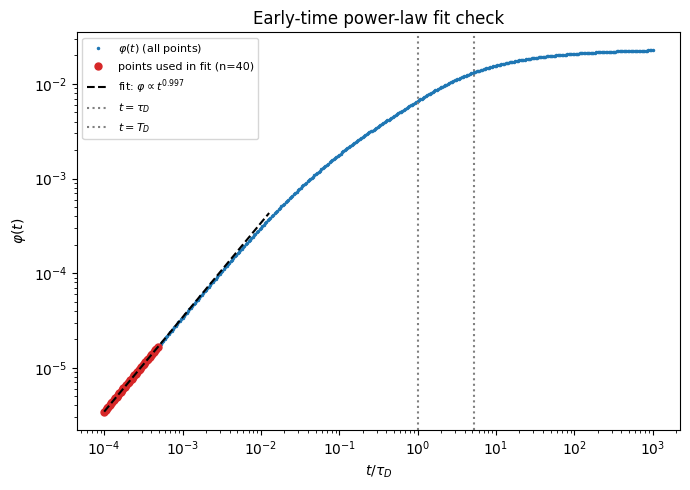

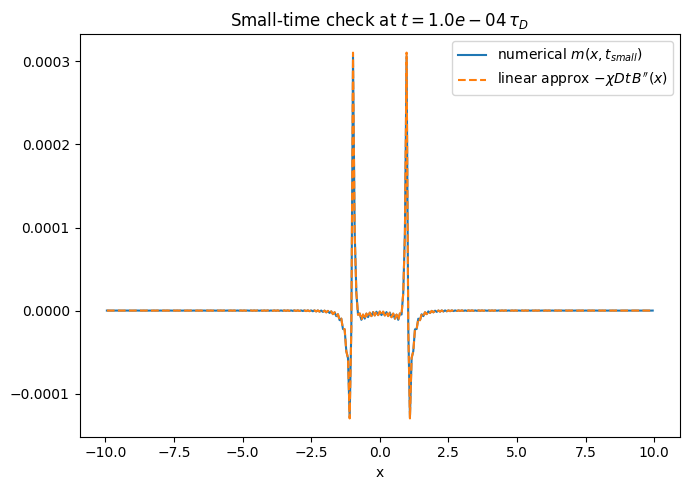

In [ ]:
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Parameters -- EDIT THESE to your actual values
# ----------------------------------------------------------------------
Z = 0.05     # depth / decay parameter in f_tilde
b = 0.3      # "slab thickness" parameter in f_tilde
W = 2.0      # width parameter in J_tilde
C = 1.0      # constant prefactor in J_tilde
D = 1.0      # diffusion coefficient
chi = 1.0    # susceptibility prefactor

# ----------------------------------------------------------------------
# Definitions (careful k->0 handling, no premature masking)
# ----------------------------------------------------------------------
def f_tilde(k, Z=Z, b=b):
    """f_tilde(k) = e^{-Z|k|} (1 - e^{-b|k|}) / |k|, with the k->0 limit = b."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk)
    small = absk < 1e-13
    out[~small] = np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / absk[~small]
    out[small] = b  # analytic k->0 limit
    return out

def J_tilde(k, C=C, W=W):
    """J_tilde(k) = (C W / 2) * J0(k W / 2)"""
    k = np.asarray(k, dtype=float)
    return (C * W / 2.0) * j0(k * W / 2.0)

def B_tilde(k, Z=Z, b=b, C=C, W=W):
    return f_tilde(k, Z, b) * J_tilde(k, C, W)

# ----------------------------------------------------------------------
# Uniform grid setup for FFT
# ----------------------------------------------------------------------
# Need: (1) fine enough dx to resolve the highest relevant k (Bessel
#           oscillations / exp(-Z k) tail), and (2) large enough box L
#           to resolve the smallest relevant k (k->0 structure) and to
#           avoid periodic wrap-around of B(x) itself.
N = 2**16                 # number of grid points
L = 4000.0                # box size in x -- must be >> W, Z and >> sqrt(D*t_max)
dx = L / N
x = (np.arange(N) - N//2) * dx          # x in [-L/2, L/2)

# FFT frequency convention: numpy's fftfreq gives cycles/sample; convert to
# angular wavenumber k = 2*pi*freq
k = 2*np.pi*np.fft.fftfreq(N, d=dx)     # this k array is in FFT order (0,+,...,-,...)

# Evaluate B_tilde(k) directly on the FFT k-grid (k=0 handled analytically above)
Bk = B_tilde(k)

# ----------------------------------------------------------------------
# Real-space B(x) via inverse FFT (as a check / for the t->infinity limit)
#   Convention used here:  B_tilde(k) = int B(x) e^{-i k x} dx
#                          B(x)       = 1/(2pi) int B_tilde(k) e^{i k x} dk
# With numpy's ifft convention (sum_n a_n e^{+2pi i k n/N}), and our k
# array built from fftfreq*2pi, the correct inversion is:
#   B(x_m) = (1/dx) * ifft( Bk )   -- see derivation notes below
# ----------------------------------------------------------------------
def inverse_transform(Fk):
    """Given F(k) sampled on our fftfreq-based k grid, return F(x) on the x grid."""
    return np.fft.ifft(Fk) / dx

Bx = inverse_transform(Bk)
# Bx should be (numerically) real; check imaginary part is negligible
print("max |Im B(x)| / max |Re B(x)| =",
      np.max(np.abs(Bx.imag)) / np.max(np.abs(Bx.real)))
Bx = Bx.real
Bx = np.fft.fftshift(Bx)   # reorder to match x (which is already monotonic)

# ----------------------------------------------------------------------
# Time-dependent solution:
#   m(x,t) = chi * theta(t) * [ B(x) - IFFT( B_tilde(k) * exp(-k^2 D t) ) ]
# ----------------------------------------------------------------------
def m_of_x_t(t):
    filt = np.exp(-k**2 * D * t)
    diffused = inverse_transform(Bk * filt).real
    diffused = np.fft.fftshift(diffused)
    return chi * (Bx - diffused)

# characteristic tau_D estimated from k_c (1/e criterion), reused from before
absB = np.abs(np.fft.fftshift(Bk))  # not meaningful ordering-wise for k=0 centering; recompute properly
k_sorted_idx = np.argsort(k)
k_sorted = k[k_sorted_idx]
absB_sorted = np.abs(Bk[k_sorted_idx])
peak = absB_sorted.max()
i_peak = np.argmax(absB_sorted)
target = peak/np.e
k_c = None
for i in range(i_peak, len(k_sorted)-1):
    if absB_sorted[i] >= target >= absB_sorted[i+1]:
        k_c = k_sorted[i] + (target-absB_sorted[i])*(k_sorted[i+1]-k_sorted[i])/(absB_sorted[i+1]-absB_sorted[i])
        break
tau_D = 1.0/(D*k_c**2)
print(f"k_c ~ {k_c:.4f},  tau_D ~ {tau_D:.4f}")

# ----------------------------------------------------------------------
# Evaluate m(x,t) at several times spanning well below/above tau_D
# ----------------------------------------------------------------------
t_list = np.array([1e-3, 1e-2, 1e-1, 1, 3, 10, 100]) * tau_D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
xmax_plot = 5*W  # zoom into the physically relevant region
mask_plot = np.abs(x) < xmax_plot
for t in t_list:
    mt = m_of_x_t(t)
    ax.plot(x[mask_plot], mt[mask_plot], label=fr'$t={t/tau_D:.3g}\,\tau_D$')
ax.plot(x[mask_plot], chi*Bx[mask_plot], 'k--', lw=1, label=r'$\chi B(x)$ (t→∞)')
ax.set_xlabel('x')
ax.set_ylabel('m(x,t)')
ax.set_title('Real-space profile at various times')
ax.legend(fontsize=8)

# time trace at a fixed observation point x0
x0 = 0.0
i0 = np.argmin(np.abs(x - x0))
t_trace = np.logspace(-4, 3, 300) * tau_D
m_trace = np.array([m_of_x_t(t)[i0] for t in t_trace])

ax = axes[1]
ax.semilogx(t_trace/tau_D, m_trace, color='tab:red')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.axhline(chi*Bx[i0], color='k', ls=':', label=r'$\chi B(x_0)$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(fr'$m(x_0={x0},t)$')
ax.set_title('Time trace at fixed x -- look for oscillatory approach')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('m_xt.png', dpi=150)
print("Saved plot to m_xt.png")

# ----------------------------------------------------------------------
# Overlap integral  phi(t) = int_{-W/2}^{W/2} m(x,t) B(x) dx
# ----------------------------------------------------------------------
mask_W = np.abs(x) <= W/2.0
x_W = x[mask_W]
B_W = Bx[mask_W]

def phi_of_t(t):
    mt = m_of_x_t(t)
    return np.trapezoid(mt[mask_W] * B_W, x_W)

t_phi = np.logspace(-4, 3, 400) * tau_D
phi_vals = np.array([phi_of_t(t) for t in t_phi])

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))

ax = axes3[0]
ax.semilogx(t_phi/tau_D, phi_vals, color='tab:blue')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(r'$\varphi(t)=\int_{-W/2}^{W/2} m(x,t)B(x)\,dx$')
ax.set_title('Overlap integral vs time (linear-y, log-x)')
ax.legend()

# log-log style plot to check for power-law regions / sign changes
ax = axes3[1]
pos = phi_vals > 0
neg = phi_vals < 0
ax.loglog(t_phi[pos]/tau_D, phi_vals[pos], '.', color='tab:blue', label=r'$\varphi>0$')
ax.loglog(t_phi[neg]/tau_D, -phi_vals[neg], '.', color='tab:red', label=r'$\varphi<0$ (shown as $|\varphi|$)')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(r'$|\varphi(t)|$')
ax.set_title(r'log-log: watch for sign flips (breaks a naive power-law fit)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phi_t.png', dpi=150)
print("Saved plot to phi_t.png")

# ----------------------------------------------------------------------
# Power-law fit to the early-time points:  phi(t) ~ A * t^p
# Fit log(phi) = log(A) + p*log(t) via linear least squares
# ----------------------------------------------------------------------
n_fit = 40  # number of earliest points to use in the fit
t_fit = t_phi[:n_fit]
T_D=1.5**2/D/tau_D
phi_fit_data = phi_vals[:n_fit]

logt = np.log(t_fit)
logphi = np.log(phi_fit_data)
p, logA = np.polyfit(logt, logphi, 1)   # slope, intercept
A = np.exp(logA)

print(f"\nEarly-time power-law fit over first {n_fit} points "
      f"(t/tau_D in [{t_fit[0]/tau_D:.2e}, {t_fit[-1]/tau_D:.2e}]):")
print(f"  phi(t) ~ A * t^p")
print(f"  p (slope)   = {p:.4f}   (expect ~1 from linear-in-t theory)")
print(f"  A           = {A:.4e}")

fig4, ax4 = plt.subplots(figsize=(7,5))
ax4.loglog(t_phi/tau_D, phi_vals, '.', color='tab:blue', ms=3, label=r'$\varphi(t)$ (all points)')
ax4.loglog(t_fit/tau_D, phi_fit_data, 'o', color='tab:red', ms=5, label=f'points used in fit (n={n_fit})')
t_line = np.array([t_fit[0], t_phi[n_fit*3]])  # extend the fit line a bit past the fitted range for visual reference
ax4.loglog(t_line/tau_D, A*t_line**p, 'k--', lw=1.5, label=fr'fit: $\varphi\propto t^{{{p:.3f}}}$')
ax4.axvline(1.0, color='gray', ls=':', label=r'$t=\tau_D$')
ax4.axvline(T_D, color='gray', ls=':', label=r'$t=T_D$')
ax4.set_xlabel(r'$t/\tau_D$')
ax4.set_ylabel(r'$\varphi(t)$')
ax4.set_title('Early-time power-law fit check')
ax4.legend(fontsize=8)
plt.tight_layout()
plt.savefig('phi_t_fit.png', dpi=150)
print("Saved plot to phi_t_fit.png")

# ----------------------------------------------------------------------
# Check the small-t linear regime numerically against -chi*D*t*B''(x)
# ----------------------------------------------------------------------
# B''(x) via spectral differentiation: FT of B'' is (ik)^2 B_tilde(k) = -k^2 Bk
Bpp = inverse_transform(-k**2 * Bk).real
Bpp = np.fft.fftshift(Bpp)

t_small = 1e-4 * tau_D
m_num = m_of_x_t(t_small)
m_lin = chi * D * t_small * (-Bpp)

fig2, ax2 = plt.subplots(figsize=(7,5))
ax2.plot(x[mask_plot], m_num[mask_plot], label='numerical $m(x,t_{small})$')
ax2.plot(x[mask_plot], m_lin[mask_plot], '--', label=r"linear approx $-\chi D t\,B''(x)$")
ax2.set_xlabel('x')
ax2.set_title(fr'Small-time check at $t={t_small/tau_D:.1e}\,\tau_D$')
ax2.legend()
plt.tight_layout()
plt.savefig('small_t_check.png', dpi=150)
print("Saved plot to small_t_check.png")

### z component

max |Im B(x)| / max |Re B(x)| = 5.731139639872419e-17
k_c ~ 1.5297,  tau_D ~ 0.4273
Saved plot to m_xt.png
Saved plot to phi_t.png

Early-time power-law fit over first 40 points (t/tau_D in [1.00e-04, 4.83e-04]):
  phi(t) ~ A * t^p
  p (slope)   = 0.9971   (expect ~1 from linear-in-t theory)
  A           = 7.8238e-02
Saved plot to phi_t_fit.png
Saved plot to p_eff_t.png

p_eff at earliest time (t=1.0e-04 tau_D):  0.9988
p_eff at t = 0.01 tau_D:  0.8836
p_eff at t = tau_D:       0.5149
p_eff at t = 100 tau_D:   0.0629
Saved plot to small_t_check.png


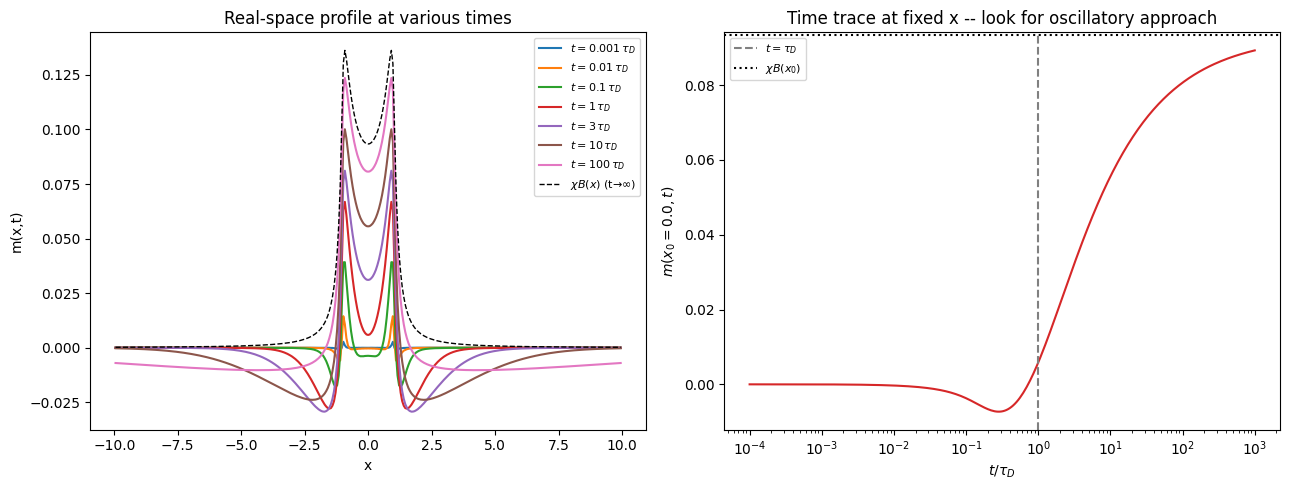

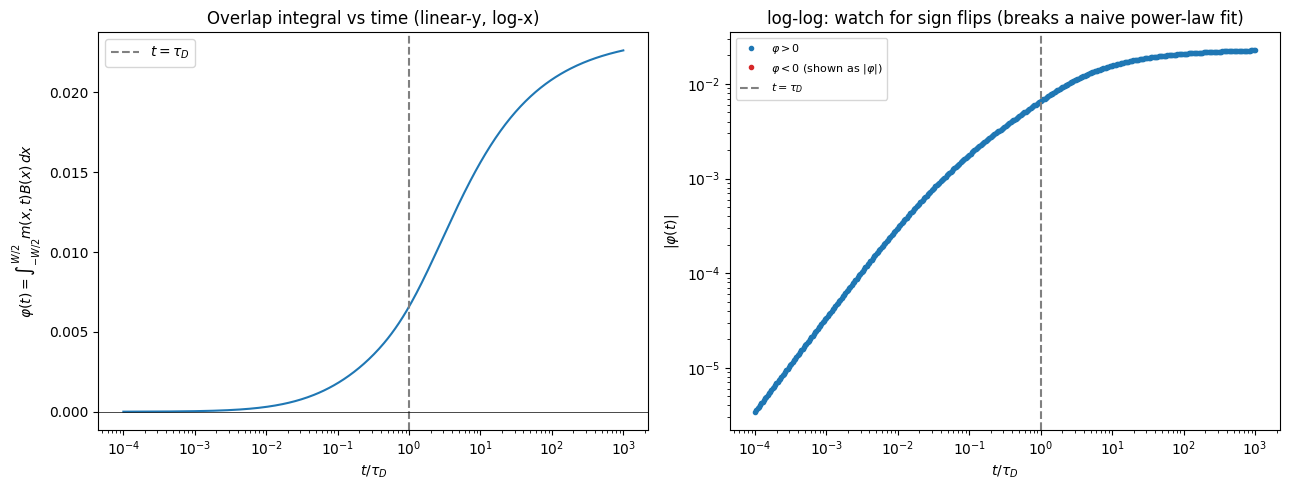

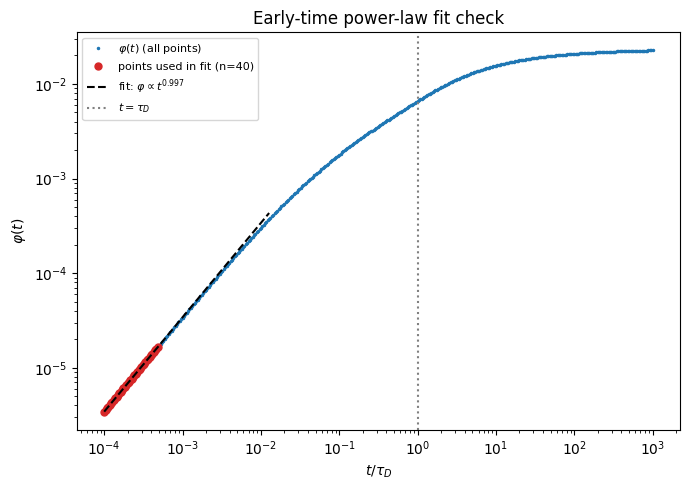

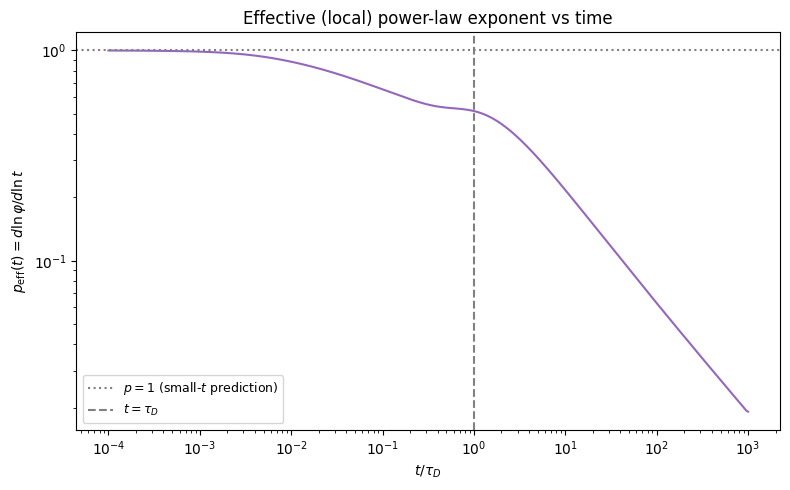

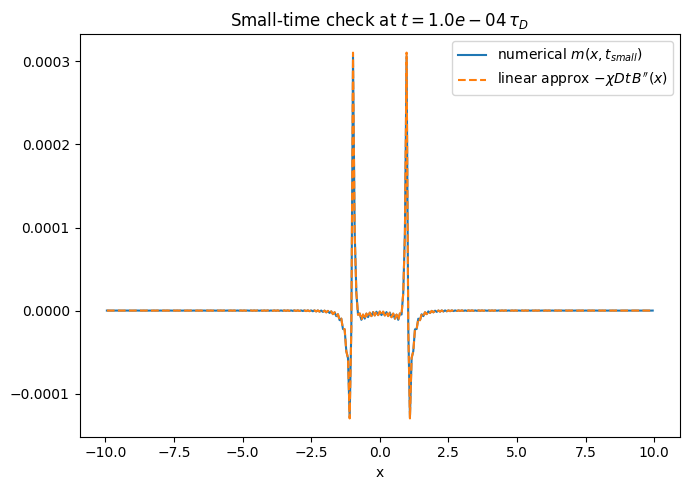

In [ ]:
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Parameters -- EDIT THESE to your actual values
# ----------------------------------------------------------------------
Z = 0.05     # depth / decay parameter in f_tilde
b = 0.3      # "slab thickness" parameter in f_tilde
W = 2.0      # width parameter in J_tilde
C = 1.0      # constant prefactor in J_tilde
D = 1.0      # diffusion coefficient
chi = 1.0    # susceptibility prefactor

# ----------------------------------------------------------------------
# Definitions (careful k->0 handling, no premature masking)
# ----------------------------------------------------------------------
def f_tilde(k, Z=Z, b=b):
    """f_tilde(k) = e^{-Z|k|} (1 - e^{-b|k|}) / |k|, with the k->0 limit = b."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk)
    small = absk < 1e-13
    out[~small] = np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / absk[~small]
    out[small] = b  # analytic k->0 limit
    return out

def J_tilde(k, C=C, W=W):
    """J_tilde(k) = (C W / 2) * J0(k W / 2)"""
    k = np.asarray(k, dtype=float)
    return (C * W / 2.0) * j0(k * W / 2.0)

def B_tilde(k, Z=Z, b=b, C=C, W=W):
    return f_tilde(k, Z, b) * J_tilde(k, C, W)

# ----------------------------------------------------------------------
# Uniform grid setup for FFT
# ----------------------------------------------------------------------
# Need: (1) fine enough dx to resolve the highest relevant k (Bessel
#           oscillations / exp(-Z k) tail), and (2) large enough box L
#           to resolve the smallest relevant k (k->0 structure) and to
#           avoid periodic wrap-around of B(x) itself.
N = 2**16                 # number of grid points
L = 4000.0                # box size in x -- must be >> W, Z and >> sqrt(D*t_max)
dx = L / N
x = (np.arange(N) - N//2) * dx          # x in [-L/2, L/2)

# FFT frequency convention: numpy's fftfreq gives cycles/sample; convert to
# angular wavenumber k = 2*pi*freq
k = 2*np.pi*np.fft.fftfreq(N, d=dx)     # this k array is in FFT order (0,+,...,-,...)

# Evaluate B_tilde(k) directly on the FFT k-grid (k=0 handled analytically above)
Bk = B_tilde(k)

# ----------------------------------------------------------------------
# Real-space B(x) via inverse FFT (as a check / for the t->infinity limit)
#   Convention used here:  B_tilde(k) = int B(x) e^{-i k x} dx
#                          B(x)       = 1/(2pi) int B_tilde(k) e^{i k x} dk
# With numpy's ifft convention (sum_n a_n e^{+2pi i k n/N}), and our k
# array built from fftfreq*2pi, the correct inversion is:
#   B(x_m) = (1/dx) * ifft( Bk )   -- see derivation notes below
# ----------------------------------------------------------------------
def inverse_transform(Fk):
    """Given F(k) sampled on our fftfreq-based k grid, return F(x) on the x grid."""
    return np.fft.ifft(Fk) / dx

Bx = inverse_transform(Bk)
# Bx should be (numerically) real; check imaginary part is negligible
print("max |Im B(x)| / max |Re B(x)| =",
      np.max(np.abs(Bx.imag)) / np.max(np.abs(Bx.real)))
Bx = Bx.real
Bx = np.fft.fftshift(Bx)   # reorder to match x (which is already monotonic)

# ----------------------------------------------------------------------
# Time-dependent solution:
#   m(x,t) = chi * theta(t) * [ B(x) - IFFT( B_tilde(k) * exp(-k^2 D t) ) ]
# ----------------------------------------------------------------------
def m_of_x_t(t):
    filt = np.exp(-k**2 * D * t)
    diffused = inverse_transform(Bk * filt).real
    diffused = np.fft.fftshift(diffused)
    return chi * (Bx - diffused)

# characteristic tau_D estimated from k_c (1/e criterion), reused from before
absB = np.abs(np.fft.fftshift(Bk))  # not meaningful ordering-wise for k=0 centering; recompute properly
k_sorted_idx = np.argsort(k)
k_sorted = k[k_sorted_idx]
absB_sorted = np.abs(Bk[k_sorted_idx])
peak = absB_sorted.max()
i_peak = np.argmax(absB_sorted)
target = peak/np.e
k_c = None
for i in range(i_peak, len(k_sorted)-1):
    if absB_sorted[i] >= target >= absB_sorted[i+1]:
        k_c = k_sorted[i] + (target-absB_sorted[i])*(k_sorted[i+1]-k_sorted[i])/(absB_sorted[i+1]-absB_sorted[i])
        break
tau_D = 1.0/(D*k_c**2)
print(f"k_c ~ {k_c:.4f},  tau_D ~ {tau_D:.4f}")

# ----------------------------------------------------------------------
# Evaluate m(x,t) at several times spanning well below/above tau_D
# ----------------------------------------------------------------------
t_list = np.array([1e-3, 1e-2, 1e-1, 1, 3, 10, 100]) * tau_D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
xmax_plot = 5*W  # zoom into the physically relevant region
mask_plot = np.abs(x) < xmax_plot
for t in t_list:
    mt = m_of_x_t(t)
    ax.plot(x[mask_plot], mt[mask_plot], label=fr'$t={t/tau_D:.3g}\,\tau_D$')
ax.plot(x[mask_plot], chi*Bx[mask_plot], 'k--', lw=1, label=r'$\chi B(x)$ (t→∞)')
ax.set_xlabel('x')
ax.set_ylabel('m(x,t)')
ax.set_title('Real-space profile at various times')
ax.legend(fontsize=8)

# time trace at a fixed observation point x0
x0 = 0.0
i0 = np.argmin(np.abs(x - x0))
t_trace = np.logspace(-4, 3, 300) * tau_D
m_trace = np.array([m_of_x_t(t)[i0] for t in t_trace])

ax = axes[1]
ax.semilogx(t_trace/tau_D, m_trace, color='tab:red')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.axhline(chi*Bx[i0], color='k', ls=':', label=r'$\chi B(x_0)$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(fr'$m(x_0={x0},t)$')
ax.set_title('Time trace at fixed x -- look for oscillatory approach')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('m_xt.png', dpi=150)
print("Saved plot to m_xt.png")

# ----------------------------------------------------------------------
# Overlap integral  phi(t) = int_{-W/2}^{W/2} m(x,t) B(x) dx
# ----------------------------------------------------------------------
mask_W = np.abs(x) <= W/2.0
x_W = x[mask_W]
B_W = Bx[mask_W]

def phi_of_t(t):
    mt = m_of_x_t(t)
    return np.trapezoid(mt[mask_W] * B_W, x_W)

t_phi = np.logspace(-4, 3, 400) * tau_D
phi_vals = np.array([phi_of_t(t) for t in t_phi])

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))

ax = axes3[0]
ax.semilogx(t_phi/tau_D, phi_vals, color='tab:blue')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(r'$\varphi(t)=\int_{-W/2}^{W/2} m(x,t)B(x)\,dx$')
ax.set_title('Overlap integral vs time (linear-y, log-x)')
ax.legend()

# log-log style plot to check for power-law regions / sign changes
ax = axes3[1]
pos = phi_vals > 0
neg = phi_vals < 0
ax.loglog(t_phi[pos]/tau_D, phi_vals[pos], '.', color='tab:blue', label=r'$\varphi>0$')
ax.loglog(t_phi[neg]/tau_D, -phi_vals[neg], '.', color='tab:red', label=r'$\varphi<0$ (shown as $|\varphi|$)')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(r'$|\varphi(t)|$')
ax.set_title(r'log-log: watch for sign flips (breaks a naive power-law fit)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phi_t.png', dpi=150)
print("Saved plot to phi_t.png")

# ----------------------------------------------------------------------
# Power-law fit to the early-time points:  phi(t) ~ A * t^p
# Fit log(phi) = log(A) + p*log(t) via linear least squares
# ----------------------------------------------------------------------
n_fit = 40  # number of earliest points to use in the fit
t_fit = t_phi[:n_fit]
phi_fit_data = phi_vals[:n_fit]

logt = np.log(t_fit)
logphi = np.log(phi_fit_data)
p, logA = np.polyfit(logt, logphi, 1)   # slope, intercept
A = np.exp(logA)

print(f"\nEarly-time power-law fit over first {n_fit} points "
      f"(t/tau_D in [{t_fit[0]/tau_D:.2e}, {t_fit[-1]/tau_D:.2e}]):")
print(f"  phi(t) ~ A * t^p")
print(f"  p (slope)   = {p:.4f}   (expect ~1 from linear-in-t theory)")
print(f"  A           = {A:.4e}")

fig4, ax4 = plt.subplots(figsize=(7,5))
ax4.loglog(t_phi/tau_D, phi_vals, '.', color='tab:blue', ms=3, label=r'$\varphi(t)$ (all points)')
ax4.loglog(t_fit/tau_D, phi_fit_data, 'o', color='tab:red', ms=5, label=f'points used in fit (n={n_fit})')
t_line = np.array([t_fit[0], t_phi[n_fit*3]])  # extend the fit line a bit past the fitted range for visual reference
ax4.loglog(t_line/tau_D, A*t_line**p, 'k--', lw=1.5, label=fr'fit: $\varphi\propto t^{{{p:.3f}}}$')
ax4.axvline(1.0, color='gray', ls=':', label=r'$t=\tau_D$')
ax4.set_xlabel(r'$t/\tau_D$')
ax4.set_ylabel(r'$\varphi(t)$')
ax4.set_title('Early-time power-law fit check')
ax4.legend(fontsize=8)
plt.tight_layout()
plt.savefig('phi_t_fit.png', dpi=150)
print("Saved plot to phi_t_fit.png")

# ----------------------------------------------------------------------
# Effective (local) power-law exponent:  p_eff(t) = d ln(phi) / d ln(t)
# Computed via central differences on the log-log data.
# Only well-defined while phi(t) > 0 (it dips negative for some params
# in the pointwise trace, but phi(t) itself, being the *integral*, was
# checked to stay positive throughout -- guard anyway for robustness).
# ----------------------------------------------------------------------
valid = phi_vals > 0
lt = np.log(t_phi[valid])
lphi = np.log(phi_vals[valid])
t_valid = t_phi[valid]

# central differences (np.gradient handles non-uniform spacing correctly)
p_eff = np.gradient(lphi, lt)

fig5, ax5 = plt.subplots(figsize=(8,5))
ax5.loglog(t_valid/tau_D, p_eff, color='tab:purple')
ax5.axhline(1.0, color='gray', ls=':', label=r'$p=1$ (small-$t$ prediction)')
ax5.axhline(0.0, color='k', lw=0.5)
ax5.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax5.set_xlabel(r'$t/\tau_D$')
ax5.set_ylabel(r'$p_{\rm eff}(t) = d\ln\varphi/d\ln t$')
ax5.set_title('Effective (local) power-law exponent vs time')
ax5.legend(fontsize=9)
plt.tight_layout()
plt.savefig('p_eff_t.png', dpi=150)
print("Saved plot to p_eff_t.png")
print(f"\np_eff at earliest time (t={t_valid[0]/tau_D:.1e} tau_D):  {p_eff[0]:.4f}")
print(f"p_eff at t = 0.01 tau_D:  {p_eff[np.argmin(np.abs(t_valid/tau_D-0.01))]:.4f}")
print(f"p_eff at t = tau_D:       {p_eff[np.argmin(np.abs(t_valid/tau_D-1.0))]:.4f}")
print(f"p_eff at t = 100 tau_D:   {p_eff[np.argmin(np.abs(t_valid/tau_D-100))]:.4f}")

# ----------------------------------------------------------------------
# Check the small-t linear regime numerically against -chi*D*t*B''(x)
# ----------------------------------------------------------------------
# B''(x) via spectral differentiation: FT of B'' is (ik)^2 B_tilde(k) = -k^2 Bk
Bpp = inverse_transform(-k**2 * Bk).real
Bpp = np.fft.fftshift(Bpp)

t_small = 1e-4 * tau_D
m_num = m_of_x_t(t_small)
m_lin = chi * D * t_small * (-Bpp)

fig2, ax2 = plt.subplots(figsize=(7,5))
ax2.plot(x[mask_plot], m_num[mask_plot], label='numerical $m(x,t_{small})$')
ax2.plot(x[mask_plot], m_lin[mask_plot], '--', label=r"linear approx $-\chi D t\,B''(x)$")
ax2.set_xlabel('x')
ax2.set_title(fr'Small-time check at $t={t_small/tau_D:.1e}\,\tau_D$')
ax2.legend()
plt.tight_layout()
plt.savefig('small_t_check.png', dpi=150)
print("Saved plot to small_t_check.png")

max |Im B(x)| / max |Re B(x)| = 3.07995417709228e-07
peak of |B_tilde(k)| located at k = 0.0016
k_c ~ 1.5300,  tau_D ~ 0.4272
Saved plot to m_xt.png
Saved plot to phi_t.png

Early-time power-law fit over first 40 points (t/tau_D in [1.00e-04, 4.83e-04]):
  |phi(t)| ~ A * t^p
  p (slope)   = 0.9766   (expect ~1 from linear-in-t theory, IF phi doesn't change sign in this window)
  A           = 2.9158e-02
  sign(phi) over fit window: constant = -1
Saved plot to phi_t_fit.png
Saved plot to p_eff_t.png

p_eff at earliest time (t=1.0e-04 tau_D):  0.9895
p_eff at t = 0.01 tau_D:  0.5561
p_eff at t = tau_D:       1.1162
p_eff at t = 100 tau_D:   0.0169
Saved plot to small_t_check.png


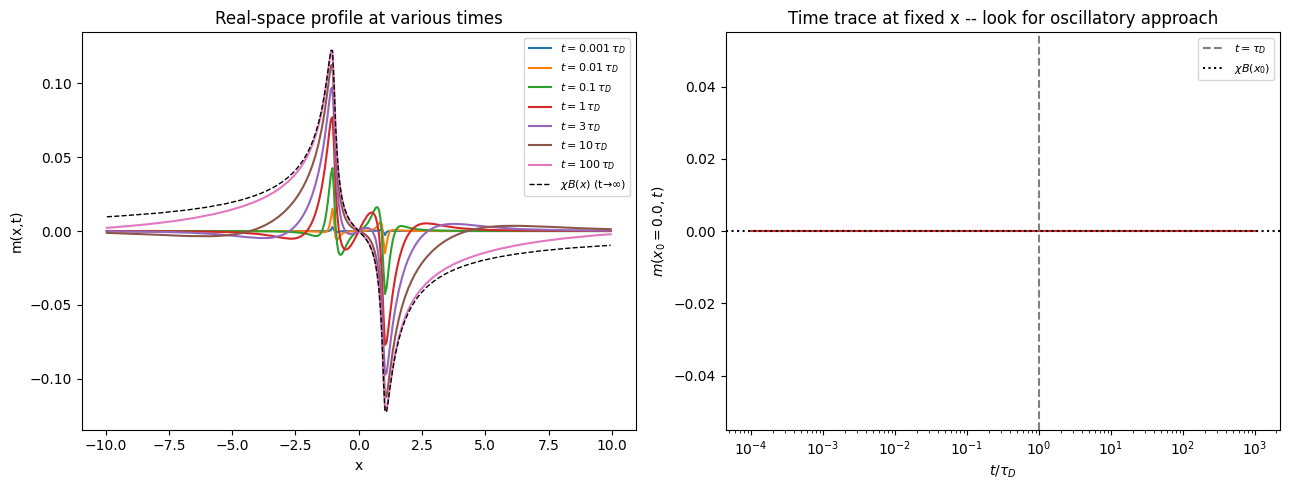

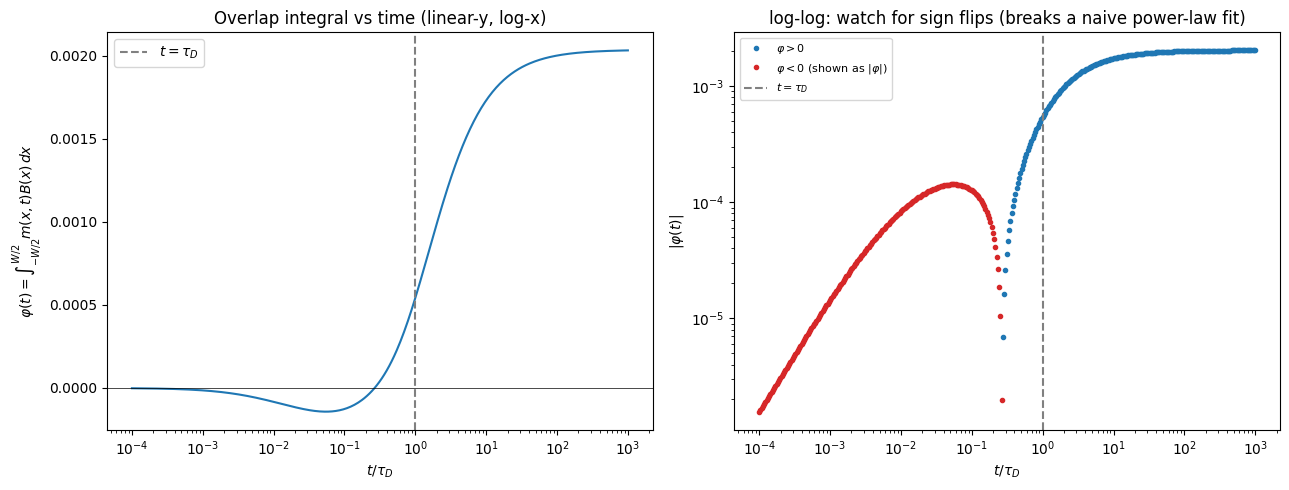

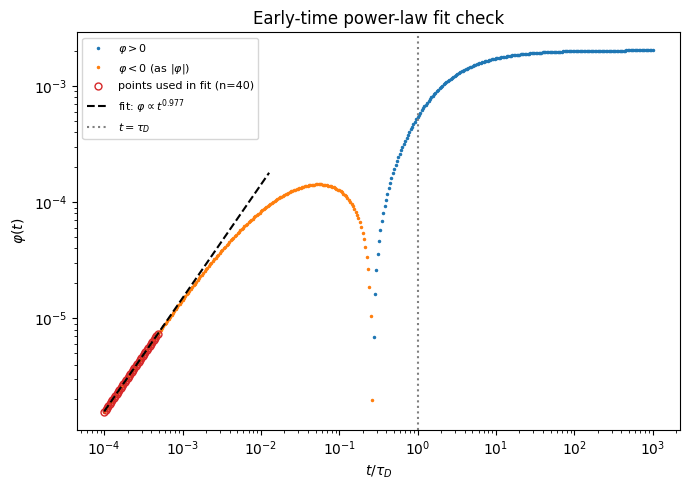

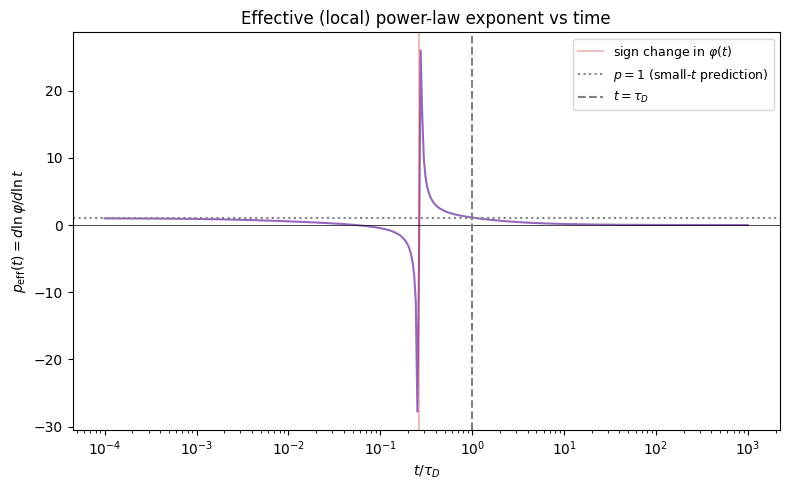

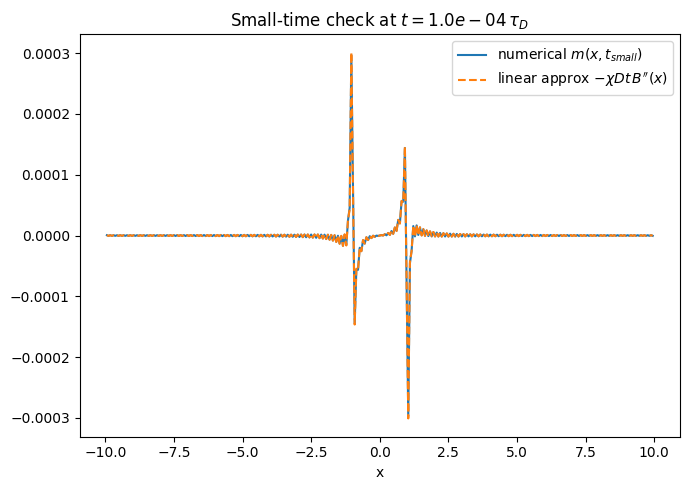

In [ ]:
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Parameters -- EDIT THESE to your actual values
# ----------------------------------------------------------------------
Z = 0.05     # depth / decay parameter in f_tilde
b = 0.3      # "slab thickness" parameter in f_tilde
W = 2.0      # width parameter in J_tilde
C = 1.0      # constant prefactor in J_tilde
D = 1.0      # diffusion coefficient
chi = 1.0    # susceptibility prefactor

# ----------------------------------------------------------------------
# Definitions (careful k->0 handling, no premature masking)
# ----------------------------------------------------------------------
def f_tilde(k, Z=Z, b=b):
    """f_tilde(k) = -1j * e^{-Z|k|} (1 - e^{-b|k|}) / k.

    Note the denominator is the signed k (not |k|): this makes f_tilde
    ODD in k, and the extra -1j makes it purely imaginary, consistent
    with the reality condition f_tilde(-k) = f_tilde(k)^*  (so that the
    inverse FFT of f_tilde, or of any product built from it, comes out
    real). At k=0 the two one-sided limits are +/- i*b (a genuine jump,
    not a removable singularity) -- we use the principal-value / odd-
    extension convention and set the k=0 point to 0 (the average of the
    two one-sided limits).
    """
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk, dtype=complex)
    small = absk < 1e-13
    out[~small] = 1j * np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / k[~small]
    out[small] = 0.0  # principal-value / odd-extension convention at k=0
    return out

def J_tilde(k, C=C, W=W):
    """J_tilde(k) = (C W / 2) * J0(k W / 2)"""
    k = np.asarray(k, dtype=float)
    return (C * W / 2.0) * j0(k * W / 2.0)

def B_tilde(k, Z=Z, b=b, C=C, W=W):
    return f_tilde(k, Z, b) * J_tilde(k, C, W)

# ----------------------------------------------------------------------
# Uniform grid setup for FFT
# ----------------------------------------------------------------------
# Need: (1) fine enough dx to resolve the highest relevant k (Bessel
#           oscillations / exp(-Z k) tail), and (2) large enough box L
#           to resolve the smallest relevant k (k->0 structure) and to
#           avoid periodic wrap-around of B(x) itself.
N = 2**16                 # number of grid points
L = 4000.0                # box size in x -- must be >> W, Z and >> sqrt(D*t_max)
dx = L / N
x = (np.arange(N) - N//2) * dx          # x in [-L/2, L/2)

# FFT frequency convention: numpy's fftfreq gives cycles/sample; convert to
# angular wavenumber k = 2*pi*freq
k = 2*np.pi*np.fft.fftfreq(N, d=dx)     # this k array is in FFT order (0,+,...,-,...)

# Evaluate B_tilde(k) directly on the FFT k-grid (k=0 handled analytically above)
Bk = B_tilde(k)

# ----------------------------------------------------------------------
# Real-space B(x) via inverse FFT (as a check / for the t->infinity limit)
#   Convention used here:  B_tilde(k) = int B(x) e^{-i k x} dx
#                          B(x)       = 1/(2pi) int B_tilde(k) e^{i k x} dk
# With numpy's ifft convention (sum_n a_n e^{+2pi i k n/N}), and our k
# array built from fftfreq*2pi, the correct inversion is:
#   B(x_m) = (1/dx) * ifft( Bk )   -- see derivation notes below
# ----------------------------------------------------------------------
def inverse_transform(Fk):
    """Given F(k) sampled on our fftfreq-based k grid, return F(x) on the x grid."""
    return np.fft.ifft(Fk) / dx

Bx = inverse_transform(Bk)
# Bx should be (numerically) real; check imaginary part is negligible
print("max |Im B(x)| / max |Re B(x)| =",
      np.max(np.abs(Bx.imag)) / np.max(np.abs(Bx.real)))
Bx = Bx.real
Bx = np.fft.fftshift(Bx)   # reorder to match x (which is already monotonic)

# ----------------------------------------------------------------------
# Time-dependent solution:
#   m(x,t) = chi * theta(t) * [ B(x) - IFFT( B_tilde(k) * exp(-k^2 D t) ) ]
# ----------------------------------------------------------------------
def m_of_x_t(t):
    filt = np.exp(-k**2 * D * t)
    diffused = inverse_transform(Bk * filt).real
    diffused = np.fft.fftshift(diffused)
    return chi * (Bx - diffused)

# characteristic tau_D estimated from k_c (1/e criterion), reused from before
absB = np.abs(np.fft.fftshift(Bk))  # not meaningful ordering-wise for k=0 centering; recompute properly
k_sorted_idx = np.argsort(k)
k_sorted = k[k_sorted_idx]
absB_sorted = np.abs(Bk[k_sorted_idx])

# Restrict to k >= 0 (the physics is symmetric in |k|; searching only the
# positive branch avoids ambiguity when |B_tilde(k)| is not peaked at k=0
# -- e.g. once f_tilde is odd, B_tilde(0) = 0 and the peak sits at some k>0).
pos = k_sorted >= 0
k_pos = k_sorted[pos]
absB_pos = absB_sorted[pos]

peak = absB_pos.max()
i_peak = np.argmax(absB_pos)
target = peak/np.e

# search for the 1/e crossing AFTER the peak (peak may now be away from k=0)
k_c = None
for i in range(i_peak, len(k_pos)-1):
    if absB_pos[i] >= target >= absB_pos[i+1]:
        k_c = k_pos[i] + (target-absB_pos[i])*(k_pos[i+1]-k_pos[i])/(absB_pos[i+1]-absB_pos[i])
        break
if k_c is None or k_c <= 0:
    # fall back to rms width if the 1/e search failed (e.g. peak at k=0
    # exactly, or no clean crossing found)
    w = absB_pos**2
    k_c = np.sqrt(np.trapezoid(k_pos**2 * w, k_pos) / np.trapezoid(w, k_pos))
    print(f"(1/e search failed or gave k_c<=0; falling back to rms width)")

tau_D = 1.0/(D*k_c**2)
print(f"peak of |B_tilde(k)| located at k = {k_pos[i_peak]:.4f}")
print(f"k_c ~ {k_c:.4f},  tau_D ~ {tau_D:.4f}")

# ----------------------------------------------------------------------
# Evaluate m(x,t) at several times spanning well below/above tau_D
# ----------------------------------------------------------------------
t_list = np.array([1e-3, 1e-2, 1e-1, 1, 3, 10, 100]) * tau_D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
xmax_plot = 5*W  # zoom into the physically relevant region
mask_plot = np.abs(x) < xmax_plot
for t in t_list:
    mt = m_of_x_t(t)
    ax.plot(x[mask_plot], mt[mask_plot], label=fr'$t={t/tau_D:.3g}\,\tau_D$')
ax.plot(x[mask_plot], chi*Bx[mask_plot], 'k--', lw=1, label=r'$\chi B(x)$ (t→∞)')
ax.set_xlabel('x')
ax.set_ylabel('m(x,t)')
ax.set_title('Real-space profile at various times')
ax.legend(fontsize=8)

# time trace at a fixed observation point x0
x0 = 0.0
i0 = np.argmin(np.abs(x - x0))
t_trace = np.logspace(-4, 3, 300) * tau_D
m_trace = np.array([m_of_x_t(t)[i0] for t in t_trace])

ax = axes[1]
ax.semilogx(t_trace/tau_D, m_trace, color='tab:red')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.axhline(chi*Bx[i0], color='k', ls=':', label=r'$\chi B(x_0)$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(fr'$m(x_0={x0},t)$')
ax.set_title('Time trace at fixed x -- look for oscillatory approach')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('m_xt.png', dpi=150)
print("Saved plot to m_xt.png")

# ----------------------------------------------------------------------
# Overlap integral  phi(t) = int_{-W/2}^{W/2} m(x,t) B(x) dx
# ----------------------------------------------------------------------
mask_W = np.abs(x) <= W/2.0
x_W = x[mask_W]
B_W = Bx[mask_W]

def phi_of_t(t):
    mt = m_of_x_t(t)
    return np.trapezoid(mt[mask_W] * B_W, x_W)

t_phi = np.logspace(-4, 3, 400) * tau_D
phi_vals = np.array([phi_of_t(t) for t in t_phi])

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))

ax = axes3[0]
ax.semilogx(t_phi/tau_D, phi_vals, color='tab:blue')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(r'$\varphi(t)=\int_{-W/2}^{W/2} m(x,t)B(x)\,dx$')
ax.set_title('Overlap integral vs time (linear-y, log-x)')
ax.legend()

# log-log style plot to check for power-law regions / sign changes
ax = axes3[1]
pos = phi_vals > 0
neg = phi_vals < 0
ax.loglog(t_phi[pos]/tau_D, phi_vals[pos], '.', color='tab:blue', label=r'$\varphi>0$')
ax.loglog(t_phi[neg]/tau_D, -phi_vals[neg], '.', color='tab:red', label=r'$\varphi<0$ (shown as $|\varphi|$)')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax.set_xlabel(r'$t/\tau_D$')
ax.set_ylabel(r'$|\varphi(t)|$')
ax.set_title(r'log-log: watch for sign flips (breaks a naive power-law fit)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phi_t.png', dpi=150)
print("Saved plot to phi_t.png")

# ----------------------------------------------------------------------
# Power-law fit to the early-time points:  phi(t) ~ A * t^p
# Fit log|phi| = log(A) + p*log(t) via linear least squares.
# NOTE: phi(t) can change sign (e.g. once f_tilde is odd, B(x) is odd,
# and phi(t) need not stay positive at small t) -- fit |phi| and track
# the sign separately, the same sign-tracking approach used in
# powerlaw_fit.py for the actual simulation data.
# ----------------------------------------------------------------------
n_fit = 40  # number of earliest points to use in the fit
t_fit = t_phi[:n_fit]
phi_fit_data = phi_vals[:n_fit]
sign_fit_data = np.sign(phi_fit_data)

if not np.all(sign_fit_data == sign_fit_data[0]):
    print(f"\nWARNING: sign of phi(t) changes within the first {n_fit} points "
          f"-- fitting |phi(t)|; a single power law is not really meaningful "
          f"across a sign change.")

logt = np.log(t_fit)
logphi = np.log(np.abs(phi_fit_data))
p, logA = np.polyfit(logt, logphi, 1)   # slope, intercept
A = np.exp(logA)

print(f"\nEarly-time power-law fit over first {n_fit} points "
      f"(t/tau_D in [{t_fit[0]/tau_D:.2e}, {t_fit[-1]/tau_D:.2e}]):")
print(f"  |phi(t)| ~ A * t^p")
print(f"  p (slope)   = {p:.4f}   (expect ~1 from linear-in-t theory, IF phi doesn't change sign in this window)")
print(f"  A           = {A:.4e}")
print(f"  sign(phi) over fit window: {'constant = ' + str(int(sign_fit_data[0])) if np.all(sign_fit_data==sign_fit_data[0]) else 'CHANGES -- see warning above'}")

fig4, ax4 = plt.subplots(figsize=(7,5))
pos_all = phi_vals > 0
neg_all = phi_vals < 0
ax4.loglog(t_phi[pos_all]/tau_D, phi_vals[pos_all], '.', color='tab:blue', ms=3, label=r'$\varphi>0$')
ax4.loglog(t_phi[neg_all]/tau_D, -phi_vals[neg_all], '.', color='tab:orange', ms=3, label=r'$\varphi<0$ (as $|\varphi|$)')
ax4.loglog(t_fit/tau_D, np.abs(phi_fit_data), 'o', color='tab:red', ms=5, mfc='none', label=f'points used in fit (n={n_fit})')
t_line = np.array([t_fit[0], t_phi[n_fit*3]])  # extend the fit line a bit past the fitted range for visual reference
ax4.loglog(t_line/tau_D, A*t_line**p, 'k--', lw=1.5, label=fr'fit: $\varphi\propto t^{{{p:.3f}}}$')
ax4.axvline(1.0, color='gray', ls=':', label=r'$t=\tau_D$')
ax4.set_xlabel(r'$t/\tau_D$')
ax4.set_ylabel(r'$\varphi(t)$')
ax4.set_title('Early-time power-law fit check')
ax4.legend(fontsize=8)
plt.tight_layout()
plt.savefig('phi_t_fit.png', dpi=150)
print("Saved plot to phi_t_fit.png")

# ----------------------------------------------------------------------
# Effective (local) power-law exponent:  p_eff(t) = d ln|phi| / d ln t
# Computed via central differences on the log-log data.
# NOTE: with the odd f_tilde, phi(t) genuinely changes sign at small t
# (see WARNING above / phi_t.png), so we take |phi| here. p_eff is then
# still meaningful as the local slope of |phi(t)| on log-log axes, but
# right at a sign crossing |phi|->0 and log|phi|->-inf, so the derivative
# there is a (removable) artifact of the sign flip, not physical -- it
# will show up as a sharp spike/dip in the p_eff plot; ignore it.
# ----------------------------------------------------------------------
valid = phi_vals != 0
lt = np.log(t_phi[valid])
lphi = np.log(np.abs(phi_vals[valid]))
t_valid = t_phi[valid]
sign_valid = np.sign(phi_vals[valid])

# central differences (np.gradient handles non-uniform spacing correctly)
p_eff = np.gradient(lphi, lt)

fig5, ax5 = plt.subplots(figsize=(8,5))
# color by sign so the (unphysical) spike at the sign crossing is visually
# distinguishable from the genuine small-t and large-t behavior
sign_change = np.where(np.diff(sign_valid) != 0)[0]
ax5.semilogx(t_valid/tau_D, p_eff, color='tab:purple')
for idx in sign_change:
    ax5.axvline(t_valid[idx]/tau_D, color='tab:red', ls='-', alpha=0.3,
                label='sign change in $\\varphi(t)$' if idx == sign_change[0] else None)
ax5.axhline(1.0, color='gray', ls=':', label=r'$p=1$ (small-$t$ prediction)')
ax5.axhline(0.0, color='k', lw=0.5)
ax5.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D$')
ax5.set_xlabel(r'$t/\tau_D$')
ax5.set_ylabel(r'$p_{\rm eff}(t) = d\ln\varphi/d\ln t$')
ax5.set_title('Effective (local) power-law exponent vs time')
ax5.legend(fontsize=9)
plt.tight_layout()
plt.savefig('p_eff_t.png', dpi=150)
print("Saved plot to p_eff_t.png")
print(f"\np_eff at earliest time (t={t_valid[0]/tau_D:.1e} tau_D):  {p_eff[0]:.4f}")
print(f"p_eff at t = 0.01 tau_D:  {p_eff[np.argmin(np.abs(t_valid/tau_D-0.01))]:.4f}")
print(f"p_eff at t = tau_D:       {p_eff[np.argmin(np.abs(t_valid/tau_D-1.0))]:.4f}")
print(f"p_eff at t = 100 tau_D:   {p_eff[np.argmin(np.abs(t_valid/tau_D-100))]:.4f}")

# ----------------------------------------------------------------------
# Check the small-t linear regime numerically against -chi*D*t*B''(x)
# ----------------------------------------------------------------------
# B''(x) via spectral differentiation: FT of B'' is (ik)^2 B_tilde(k) = -k^2 Bk
Bpp = inverse_transform(-k**2 * Bk).real
Bpp = np.fft.fftshift(Bpp)

t_small = 1e-4 * tau_D
m_num = m_of_x_t(t_small)
m_lin = chi * D * t_small * (-Bpp)

fig2, ax2 = plt.subplots(figsize=(7,5))
ax2.plot(x[mask_plot], m_num[mask_plot], label='numerical $m(x,t_{small})$')
ax2.plot(x[mask_plot], m_lin[mask_plot], '--', label=r"linear approx $-\chi D t\,B''(x)$")
ax2.set_xlabel('x')
ax2.set_title(fr'Small-time check at $t={t_small/tau_D:.1e}\,\tau_D$')
ax2.legend()
plt.tight_layout()
plt.savefig('small_t_check.png', dpi=150)
print("Saved plot to small_t_check.png")

## setup for comparison

In [ ]:
n=1e-9
phi0 = h / (2 * e)

um = 1e-6

W_um=5
# Parameters in SI
I_SC = 1e3 * 1e-6      # A
lam = 0.07 * um        # m
b   = 0.1 * um         # m
W   = W_um * um         # m
gamma = 0.2236

mu_B = physical_constants['Bohr magneton'][0]  # A m^2
g = 1.0
mu_s = mu_B

lam_tilde = lam**2 / (b * W)

prefactor_J = (2 * I_SC) / (np.pi * b * W * (1 - gamma * np.sqrt(2 * lam_tilde)))

def J_SC(u):
    u = np.asarray(u)
    au = np.abs(u)
    J = np.zeros_like(u, dtype=float)

    edge = (au > (1 - lam_tilde)) & (au <= 1.0)
    bulk = au <= (1 - lam_tilde)

    J[edge] = (1 / np.sqrt(2 * lam_tilde)) * np.exp(-(1 - lam_tilde - au[edge]) / (2 * lam_tilde))
    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J

def compute_flux(X_vals_m, Z_m, Nu=6000):
    u = np.linspace(-1.0, 1.0, Nu)
    x_u = 0.5 * W * u
    J_ratio = J_SC(u) / I_SC

    dx = x_u[:, None] - X_vals_m[None, :]
    log_term = np.log((dx**2 + Z_m**2) / (dx**2 + (Z_m + b)**2))
    atan_term = np.arctan2(Z_m + b, dx) - np.arctan2(Z_m, dx)

    integral_fx = np.trapezoid(J_ratio[:, None] * log_term, u, axis=0)
    integral_fz = np.trapezoid(J_ratio[:, None] * atan_term, u, axis=0)

    Fx = -(g * mu_s * mu_0 * W / (8 * np.pi)) * integral_fx
    Fz =  (g * mu_s * mu_0 * W / (4 * np.pi)) * integral_fz

    return Fx, Fz

Z_um = 0.05
Z_m = Z_um * um

X_um = np.linspace(-4.0, 4.0, 800)
X_m = X_um * um

Fx, Fz = compute_flux(X_m, Z_m, Nu=7000)
Fx=Fx/(n*phi0)
Fz=Fz/(n*phi0)

N = 2**16
L = 2000*W
dx = L / N
x = (np.arange(N) - N//2) * dx

def make_flux_interpolators(
    Z_m,
    x_full,
    W,
    n_center=600,
    n_tail=100,
    Nu=7000
):

    xmax = np.max(np.abs(x_full))

    # Dense region around the strip
    x_center = np.linspace(
        -10*W,
        10*W,
        n_center
    )

    # Positive logarithmic tail
    x_tail_pos = np.geomspace(
        10*W,
        xmax,
        n_tail
    )

    # Negative tail
    x_tail_neg = -x_tail_pos[::-1]

    x_coarse = np.unique(
        np.concatenate([
            x_tail_neg,
            x_center,
            x_tail_pos
        ])
    )

    Fx_coarse, Fz_coarse = compute_flux(
        x_coarse,
        Z_m,
        Nu=Nu
    )

    Fx_interp = CubicSpline(x_coarse, Fx_coarse)
    Fz_interp = CubicSpline(x_coarse, Fz_coarse)

    return Fx_interp, Fz_interp

# Precompute once
Fx_interp, Fz_interp = make_flux_interpolators(
    Z_m,
    x,
    W,
    n_center=1000,
    n_tail=150,
    Nu=7000
)

# Cheap evaluation on the full grid
Bx_num = Fx_interp(x) / (n * phi0)
Bz_num = Fz_interp(x) / (n * phi0)

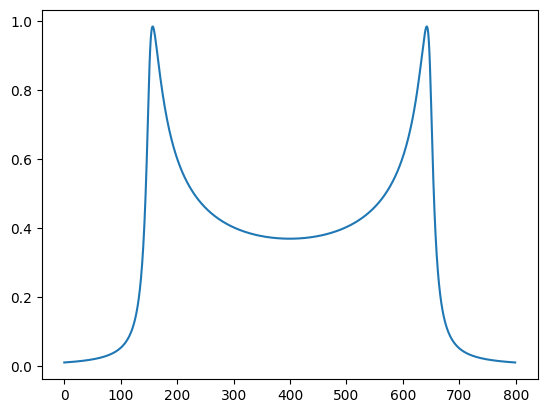

In [ ]:
#plt.plot(x[abs(x)<10/um],Bx_num[abs(x)<10/um])
plt.plot(Fx)

W = 5.0 um
Interpolation interval: -20.0 to 20.0 um
Full x range: -4999.999999999999 to 4999.847412109375 um
Number of full-grid points: 65536
Number of interpolation points: 1000
DIRECT:
max Fx = 0.9836117150950997
max Fz = 1.004132464119883

INTERPOLATOR ON FINE TEST GRID:
max Fx = 1.0007420789421115
max Fz = 0.9992454238213195

INTERPOLATOR ON FULL FFT GRID:
max Fx = 0.9907039419825769
max Fz = 0.9672854105229661

Grid spacings:
original direct dx = 0.01001251564455563 um
full FFT dx = 0.15258789062486122 um


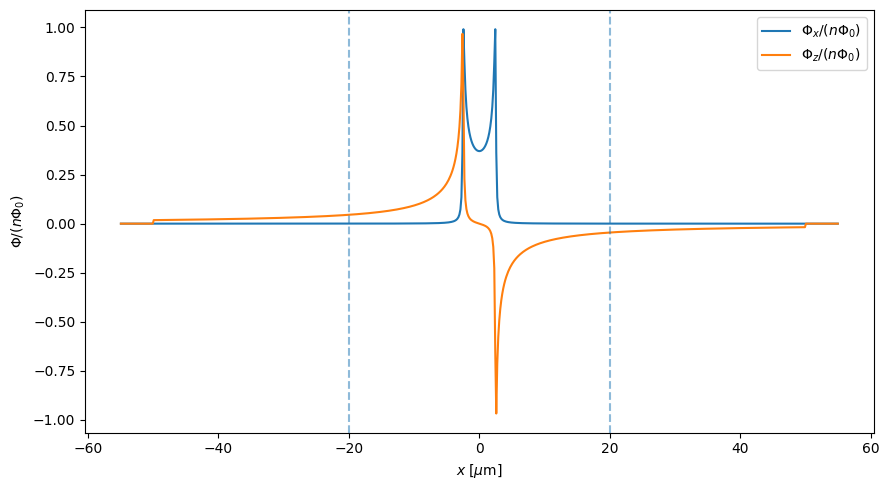

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline
from scipy.constants import h, e, mu_0, physical_constants


# ============================================================
# Constants and parameters
# ============================================================

n = 1e-9

phi0 = h / (2 * e)

um = 1e-6

W_um = 5.0

# Parameters in SI
I_SC = 1e3 * 1e-6       # A
lam = 0.07 * um         # m
b = 0.1 * um            # m
W = W_um * um           # m

gamma = 0.2236

mu_B = physical_constants["Bohr magneton"][0]   # A m^2
g = 1.0
mu_s = mu_B

lam_tilde = lam**2 / (b * W)

prefactor_J = (
    2 * I_SC
    / (
        np.pi
        * b
        * W
        * (1 - gamma * np.sqrt(2 * lam_tilde))
    )
)


# ============================================================
# Superconducting current density
# ============================================================

def J_SC(u):

    u = np.asarray(u)

    au = np.abs(u)

    J = np.zeros_like(u, dtype=float)

    edge = (
        (au > (1 - lam_tilde))
        & (au <= 1.0)
    )

    bulk = au <= (1 - lam_tilde)

    J[edge] = (
        1 / np.sqrt(2 * lam_tilde)
        * np.exp(
            -(1 - lam_tilde - au[edge])
            / (2 * lam_tilde)
        )
    )

    J[bulk] = 1 / np.sqrt(1 - u[bulk]**2)

    return prefactor_J * J


# ============================================================
# Direct flux calculation
# ============================================================

def compute_flux(X_vals_m, Z_m, Nu=7000):

    # Integration coordinate across the strip
    u = np.linspace(-1.0, 1.0, Nu)

    # Physical x coordinate across strip
    x_u = 0.5 * W * u

    # Current normalized by total current
    J_ratio = J_SC(u) / I_SC

    # Difference between source coordinate and observation coordinate
    dx = x_u[:, None] - X_vals_m[None, :]

    # Magnetic-field kernels
    log_term = np.log(
        (dx**2 + Z_m**2)
        /
        (dx**2 + (Z_m + b)**2)
    )

    atan_term = (
        np.arctan2(Z_m + b, dx)
        -
        np.arctan2(Z_m, dx)
    )

    # Integrate over u
    integral_fx = np.trapezoid(
        J_ratio[:, None] * log_term,
        u,
        axis=0
    )

    integral_fz = np.trapezoid(
        J_ratio[:, None] * atan_term,
        u,
        axis=0
    )

    # Flux components
    Fx = (
        -g * mu_s * mu_0 * W
        / (8 * np.pi)
        * integral_fx
    )

    Fz = (
        g * mu_s * mu_0 * W
        / (4 * np.pi)
        * integral_fz
    )

    return Fx, Fz


# ============================================================
# FULL x GRID
# ============================================================

N = 2**16

L = 2000 * W

dx = L / N

x = (
    np.arange(N) - N // 2
) * dx


# ============================================================
# INTERPOLATOR
#
# Direct calculation only on:
#
#       -4W <= x <= 4W
#
# Outside this interval:
#
#       Fx = Fz = 0
# ============================================================

def make_flux_interpolators(
    Z_m,
    x_full,
    n_coarse=40000,
    Nu=7000
):

    # --------------------------------------------------------
    # Physical interval where flux is calculated
    # --------------------------------------------------------

    x_min = -10 * W
    x_max =  10 * W

    # Coarse grid ONLY inside [-4W, 4W]
    x_coarse = np.linspace(
        x_min,
        x_max,
        n_coarse
    )

    # --------------------------------------------------------
    # Calculate flux on coarse grid
    # --------------------------------------------------------

    Fx_coarse, Fz_coarse = compute_flux(
        x_coarse,
        Z_m,
        Nu=Nu
    )

    # --------------------------------------------------------
    # Build interpolators
    # --------------------------------------------------------

    Fx_spline = CubicSpline(
        x_coarse,
        Fx_coarse
    )

    Fz_spline = CubicSpline(
        x_coarse,
        Fz_coarse
    )

    # --------------------------------------------------------
    # Evaluate on FULL x grid
    # --------------------------------------------------------

    Fx_full = np.zeros_like(x_full, dtype=float)
    Fz_full = np.zeros_like(x_full, dtype=float)

    # Mask corresponding to [-4W, 4W]
    mask = (
        (x_full >= x_min)
        & (x_full <= x_max)
    )

    # Interpolate ONLY inside physical interval
    Fx_full[mask] = Fx_spline(x_full[mask])
    Fz_full[mask] = Fz_spline(x_full[mask])

    return (
        Fx_full,
        Fz_full,
        x_coarse,
        Fx_coarse,
        Fz_coarse
    )


# ============================================================
# Z POSITION
# ============================================================

Z_um = 0.05

Z_m = Z_um * um


# ============================================================
# COMPUTE INTERPOLATED FLUX
# ============================================================

Fx_num, Fz_num, x_coarse, Fx_coarse, Fz_coarse = (
    make_flux_interpolators(
        Z_m,
        x,
        n_coarse=1000,
        Nu=7000
    )
)


# ============================================================
# Convert to units of n * Phi_0
# ============================================================

Fx_num = Fx_num / (n * phi0)

Fz_num = Fz_num / (n * phi0)


# ============================================================
# CHECK
# ============================================================

print("W =", W / um, "um")

print(
    "Interpolation interval:",
    -4 * W / um,
    "to",
    4 * W / um,
    "um"
)

print(
    "Full x range:",
    x.min() / um,
    "to",
    x.max() / um,
    "um"
)

print(
    "Number of full-grid points:",
    len(x)
)

print(
    "Number of interpolation points:",
    len(x_coarse)
)


# Direct calculation on the original fine grid
X_test_um = np.linspace(-4.0, 4.0, 800)
X_test_m = X_test_um * um

Fx_direct, Fz_direct = compute_flux(
    X_test_m,
    Z_m,
    Nu=7000
)

Fx_direct_norm = Fx_direct / (n * phi0)
Fz_direct_norm = Fz_direct / (n * phi0)


# Interpolator evaluated on EXACTLY the same points
Fx_interp_test = CubicSpline(
    x_coarse,
    Fx_coarse
)(X_test_m)

Fz_interp_test = CubicSpline(
    x_coarse,
    Fz_coarse
)(X_test_m)

Fx_interp_test /= n * phi0
Fz_interp_test /= n * phi0


print("DIRECT:")
print("max Fx =", np.max(Fx_direct_norm))
print("max Fz =", np.max(Fz_direct_norm))

print("\nINTERPOLATOR ON FINE TEST GRID:")
print("max Fx =", np.max(Fx_interp_test))
print("max Fz =", np.max(Fz_interp_test))


# Now evaluate interpolator on your actual full FFT grid
Fx_full_norm = Fx_num
Fz_full_norm = Fz_num

mask_plot = np.abs(x / um) < 4 * W_um

print("\nINTERPOLATOR ON FULL FFT GRID:")
print("max Fx =", np.max(Fx_full_norm[mask_plot]))
print("max Fz =", np.max(Fz_full_norm[mask_plot]))

print("\nGrid spacings:")
print(
    "original direct dx =",
    X_test_um[1] - X_test_um[0],
    "um"
)

print(
    "full FFT dx =",
    (x[1] - x[0]) / um,
    "um"
)
# ============================================================
# PLOT
# ============================================================

x_um = x / um

plt.figure(figsize=(9, 5))

plt.plot(
    x_um[abs(x_um)<11*W_um],
    Fx_num[abs(x_um)<11*W_um],
    label=r"$\Phi_x/(n\Phi_0)$"
)

plt.plot(
    x_um[abs(x_um)<11*W_um],
    Fz_num[abs(x_um)<11*W_um],
    label=r"$\Phi_z/(n\Phi_0)$"
)

plt.axvline(
    -4 * W / um,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    4 * W / um,
    linestyle="--",
    alpha=0.5
)

plt.xlabel(r"$x\;[\mu\mathrm{m}]$")
plt.ylabel(r"$\Phi/(n\Phi_0)$")

# plt.xlim(
#     x.min() / um,
#     x.max() / um
# )

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Bx_num = Fx_num
Bz_num = Fz_num

In [ ]:
for name, c in CASES.items():
  print(name)
  #print(type(name))

even
odd


### First approach to solving in real space

In [ ]:
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
from scipy.interpolate import interp1d, CubicSpline
from scipy.special import jv


# ============================================================
# Constants
# ============================================================

phi0 = h / (2 * e)
n=1e-9
um = 1e-6

# ============================================================
# User parameters
# ============================================================

I_target_nA = 6.3
I_target = I_target_nA * 1e-9   # A

b_um = 0.1
b = b_um * um

lam_um = 0.07
lam = lam_um * um

gamma = 0.2236
g = 1.0

mu_B = physical_constants['Bohr magneton'][0]
mu_s = mu_B

# FastHenry cut window
y_min_um = -7.5
y_max_um = -2.5
y_center_um = 0.5 * (y_min_um + y_max_um)

# SC width
W_um = 5.0
W = W_um * um

# Field observation height
Z_um = 0.05
Z_m = Z_um * um

# Monte Carlo / noise settings
sigma_m2 = 5e17
sigma_um2 = sigma_m2 * 1e-12

lam_tilde = lam**2 / (b * W)

K=1
K=-g*mu_s*mu_0*W/(8*np.pi*I_target*1e-9*phi0)
C=K*2*I_target/(np.pi*b*W*(1-gamma*np.sqrt(2*lam_tilde)))


# ----------------------------------------------------------------------
# Parameters -- EDIT THESE to your actual values
# ----------------------------------------------------------------------
Z = Z_um    # depth / decay parameter in f_tilde
b = b_um      # "slab thickness" parameter in f_tilde
W = W_um      # width parameter in J_tilde
#C = 1.0      # constant prefactor in J_tilde
D = 1.0e5      # diffusion coefficient
chi = 1.0    # susceptibility prefactor

# ----------------------------------------------------------------------
# The two f_tilde variants
# ----------------------------------------------------------------------
def f_tilde_even(k, Z=Z, b=b):
    """f_tilde(k) = e^{-Z|k|} (1 - e^{-b|k|}) / |k|, with the k->0 limit = b.
    Real and EVEN in k -> B(x) real and EVEN in x."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk, dtype=complex)  # complex dtype for uniformity with the odd case
    small = absk < 1e-13
    out[~small] = -2*np.pi*np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / absk[~small]
    out[small] = -2*np.pi*b  # analytic k->0 limit
    return out

def f_tilde_odd(k, Z=Z, b=b):
    """f_tilde(k) = -1j * e^{-Z|k|} (1 - e^{-b|k|}) / k  (signed k in denominator).
    Purely imaginary and ODD in k -> B(x) real and ODD in x.
    At k=0 the one-sided limits are +/- i*b (genuine jump); we use the
    principal-value / odd-extension convention: value 0 at k=0."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk, dtype=complex)
    small = absk < 1e-13
    out[~small] = -2*np.pi*1j * np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / k[~small]
    out[small] = 0.0
    return out

def J_tilde(k, C=C, W=W, N=32):
    """J_tilde(k) = (C W / 2) * J0(k W / 2)  -- real, even in k."""

    alpha=1-2*np.acos(1-lam_tilde)/np.pi
    w=W*lam_tilde
    print(alpha)
    k = np.asarray(k, dtype=float)
    J =(alpha*np.pi*j0(k * W / 2.0))
    for n in range(1, N+1):
        coeff = 2*np.sin(np.pi*n*alpha)/n
        J += coeff*jv(2*n, k*W/2.0)
    den = k**2 + 1/W**2
    a = 1.0 / (lam_tilde * W)
    I = (
        2
        * (
            np.exp(a * w / 2)
            * (
                k * np.sin(k * W / 2)
                + a * np.cos(k * W / 2)
            )
            - (
                k * np.sin(k * (W - w) / 2)
                + a * np.cos(k * (W - w) / 2)
            )
        )
        / (k**2 + a**2)
    )
    J += (1/np.sqrt(2*lam_tilde))*I
    return (C) * J

CASES = {
    'even': dict(f=f_tilde_even, color='tab:blue',   label=r'even $\tilde f$ (real, symmetric $B$)'),
    'odd':  dict(f=f_tilde_odd,  color='tab:orange', label=r'odd $\tilde f$ (imaginary, antisymmetric $B$)'),
}

# ----------------------------------------------------------------------
# Uniform grid setup for FFT (shared by both cases)
# ----------------------------------------------------------------------
N = 2**16
L = 2000*W
dx = L / N
x = (np.arange(N) - N//2) * dx

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

def inverse_transform(Fk):
    """Given F(k) sampled on our fftfreq-based k grid, return F(x) on the x grid."""
    return np.fft.ifft(Fk) / dx

# ----------------------------------------------------------------------
# Build B_tilde(k), B(x), and k_c/tau_D for each case
# ----------------------------------------------------------------------
def find_kc_tauD(Bk_case, k, D):
    """Robust k_c extraction: search the peak of |B_tilde(k)| restricted to
    k>=0 (handles both k=0-peaked and away-from-zero-peaked spectra), with
    an rms-width fallback."""
    idx = np.argsort(k)
    k_sorted = k[idx]
    absB_sorted = np.abs(Bk_case[idx])
    pos = k_sorted >= 0
    k_pos = k_sorted[pos]
    absB_pos = absB_sorted[pos]

    peak = absB_pos.max()
    i_peak = np.argmax(absB_pos)
    target = peak/np.e
    k_c = None
    for i in range(i_peak, len(k_pos)-1):
        if absB_pos[i] >= target >= absB_pos[i+1]:
            k_c = k_pos[i] + (target-absB_pos[i])*(k_pos[i+1]-k_pos[i])/(absB_pos[i+1]-absB_pos[i])
            break
    if k_c is None or k_c <= 0:
        w = absB_pos**2
        k_c = np.sqrt(np.trapezoid(k_pos**2 * w, k_pos) / np.trapezoid(w, k_pos))
    tau_D = 1.0/(D*k_c**2)
    return k_c, tau_D, k_pos[i_peak]

for name, c in CASES.items():
    Bk_case = c['f'](k) * J_tilde(k)
    Bx_case = inverse_transform(Bk_case)
    im_ratio = np.max(np.abs(Bx_case.imag)) / np.max(np.abs(Bx_case.real))
    Bx_case = np.fft.fftshift(Bx_case.real)
    k_c, tau_D, k_peak = find_kc_tauD(Bk_case, k, D)

    c['Bk'] = Bk_case
    c['Bx'] = Bx_case
    c['k_c'] = k_c
    c['tau_D'] = tau_D
    print(f"[{name}] max|Im B(x)|/max|Re B(x)| = {im_ratio:.2e}   "
          f"peak|B_tilde(k)| at k={k_peak:.4f}   k_c={k_c:.4f}   tau_D={tau_D:.4f}")

def make_m_of_x_t(Bx_num, Bz_num, x, D, chi):
    """
    Same diffusive-relaxation formula as make_m_of_x_t, but sourced from
    the numerical (compute_flux/n/phi0) B-fields instead of the analytical
    f_tilde/J_tilde construction.
    """
    dx = x[1] - x[0]
    Npts = len(x)
    Npad = 2 * Npts
    k_pad = 2 * np.pi * np.fft.fftfreq(Npad, d=dx)

    B_hat_cache = {}
    for name, B in (("even", Bx_num), ("odd", Bz_num)):
        B_padded = np.zeros(Npad)
        B_padded[:Npts] = B
        B_hat_cache[name] = np.fft.fft(B_padded)

    B_cache = {"even": Bx_num, "odd": Bz_num}

    def m_of_x_t_numeric(t, name="even"):
        if t <= 0:
            return np.zeros_like(x)
        B = B_cache[name]
        B_hat = B_hat_cache[name]
        kernel_hat = np.exp(-D * t * k_pad**2)
        conv = np.real(np.fft.ifft(B_hat * kernel_hat))[:Npts]
        return chi * (B - conv)

    return m_of_x_t_numeric

m_of_x_t = make_m_of_x_t(Bx_num, Bz_num, x, D, chi)

# Use a single shared tau_D (e.g. the max of the two) so both cases are
# animated/plotted on a common, physically meaningful time axis.
tau_D_shared = max(c['tau_D'] for c in CASES.values())
print(f"\nUsing shared tau_D = {tau_D_shared:.4f} (max of the two cases) "
      f"for common time axis in plots/animation.")

# ========================================================================
# ANIMATION: m(x,t) for both cases, side by side in time
# ========================================================================
xmax_plot = 6*W
mask_plot = np.abs(x) < xmax_plot
x_plot = x[mask_plot]

t_anim = np.logspace(-4, 3, 150) * tau_D_shared  # log-spaced frames

B_num_cache = {"even": Bx_num, "odd": Bz_num}
plot_style = {
    "even": dict(color='tab:blue',   label=r'even (numeric $B_x$)'),
    "odd":  dict(color='tab:orange', label=r'odd (numeric $B_z$)'),
}

fig_anim, ax_anim = plt.subplots(figsize=(8, 5.5))
lines = {}
for name, style in plot_style.items():
    (line,) = ax_anim.plot([], [], color=style['color'], lw=2, label=style['label'])
    lines[name] = line
    ax_anim.plot(x_plot, chi*B_num_cache[name][mask_plot], color=style['color'],
                 lw=1, ls=':', alpha=0.6)

# fix y-limits from the envelope of both saturation profiles so the frame
# doesn't rescale during the animation
ymax = max(np.max(np.abs(chi*B_num_cache[name][mask_plot])) for name in plot_style)
ax_anim.set_xlim(x_plot.min(), x_plot.max())
ax_anim.set_ylim(-1.3*ymax, 1.3*ymax)
ax_anim.axhline(0, color='k', lw=0.5)
ax_anim.set_xlabel('x')
ax_anim.set_ylabel('m(x,t)')
ax_anim.legend(loc='upper right', fontsize=9)
time_text = ax_anim.text(0.02, 0.95, '', transform=ax_anim.transAxes, fontsize=11,
                          verticalalignment='top')

def init():
    for name in plot_style:
        lines[name].set_data([], [])
    time_text.set_text('')
    return list(lines.values()) + [time_text]

def update(frame):
    t = t_anim[frame]
    for name in plot_style:
        mt = m_of_x_t(t, name)
        lines[name].set_data(x_plot, mt[mask_plot])
    time_text.set_text(fr'$t = {t/tau_D_shared:.3g}\,\tau_D^{{\rm shared}}$')
    return list(lines.values()) + [time_text]

anim = animation.FuncAnimation(fig_anim, update, frames=len(t_anim),
                                init_func=init, blit=True, interval=60)
anim.save('m_xt_numeric_animation.gif', writer='pillow', fps=18, dpi=110)
plt.close(fig_anim)
print("Saved animation to m_xt_numeric_animation.gif")
print("Saved animation to m_xt_animation.gif")

# ========================================================================
# Overlap integrals for each case, and their SUM
# ========================================================================
mask_W = np.abs(x) <= W/2.0
x_W = x[mask_W]

def phi_of_t(case, t):
    mt = m_of_x_t(t, name)
    B_W = case['Bx'][mask_W]
    return np.trapezoid(mt[mask_W] * B_W, x_W)

t_phi = np.logspace(-6, 3, 400) * tau_D_shared

phi_vals = {}
for name, c in CASES.items():
    phi_vals[name] = np.array([phi_of_t(c, t) for t in t_phi])

phi_sum = sum(phi_vals.values())  # combined overlap integral used for fits from here on

# ---- Plot: individual overlaps + their sum ----
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))

ax = axes3[0]
for name, c in CASES.items():
    ax.semilogx(t_phi/tau_D_shared, phi_vals[name], color=c['color'], label=fr'$\varphi_{{\rm {name}}}(t)$')
ax.semilogx(t_phi/tau_D_shared, phi_sum, color='k', lw=2, label=r'$\varphi_{\rm sum}(t)$')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D^{\rm shared}$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$t/\tau_D^{\rm shared}$')
ax.set_ylabel(r'$\varphi(t)$')
ax.set_title('Overlap integrals: individual cases and their sum')
ax.legend(fontsize=8)

ax = axes3[1]
pos = phi_sum > 0
neg = phi_sum < 0
ax.loglog(t_phi[pos]/tau_D_shared, phi_sum[pos], '.', color='k', ms=3, label=r'$\varphi_{\rm sum}>0$')
ax.loglog(t_phi[neg]/tau_D_shared, -phi_sum[neg], '.', color='tab:red', ms=3, label=r'$\varphi_{\rm sum}<0$ (as $|\cdot|$)')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D^{\rm shared}$')
ax.set_xlabel(r'$t/\tau_D^{\rm shared}$')
ax.set_ylabel(r'$|\varphi_{\rm sum}(t)|$')
ax.set_title('Summed overlap integral, log-log (watch for sign flips)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phi_t_combined.png', dpi=150)
print("Saved plot to phi_t_combined.png")

# ========================================================================
# Power-law fit (early time) and effective exponent, on phi_sum
# ========================================================================
n_fit = 40
t_fit = t_phi[:n_fit]
phi_fit_data = phi_sum[:n_fit]
sign_fit_data = np.sign(phi_fit_data)

if not np.all(sign_fit_data == sign_fit_data[0]):
    print(f"\nWARNING: sign of phi_sum(t) changes within the first {n_fit} points "
          f"-- fitting |phi_sum(t)|; interpret the exponent with care.")

logt = np.log(t_fit)
logphi = np.log(np.abs(phi_fit_data))
p, logA = np.polyfit(logt, logphi, 1)
A = np.exp(logA)

print(f"\nEarly-time power-law fit of phi_sum over first {n_fit} points "
      f"(t/tau_D in [{t_fit[0]/tau_D_shared:.2e}, {t_fit[-1]/tau_D_shared:.2e}]):")
print(f"  |phi_sum(t)| ~ A * t^p")
print(f"  p (slope) = {p:.4f}   (expect ~1 from linear-in-t theory)")
print(f"  A         = {A:.4e}")
print(f"  sign(phi_sum) over fit window: "
      f"{'constant = ' + str(int(sign_fit_data[0])) if np.all(sign_fit_data==sign_fit_data[0]) else 'CHANGES'}")

fig4, ax4 = plt.subplots(figsize=(7,5))
pos_all = phi_sum > 0
neg_all = phi_sum < 0
ax4.loglog(t_phi[pos_all]/tau_D_shared, phi_sum[pos_all], '.', color='k', ms=3, label=r'$\varphi_{\rm sum}>0$')
ax4.loglog(t_phi[neg_all]/tau_D_shared, -phi_sum[neg_all], '.', color='tab:red', ms=3, label=r'$\varphi_{\rm sum}<0$ (as $|\cdot|$)')
ax4.loglog(t_fit/tau_D_shared, np.abs(phi_fit_data), 'o', color='tab:green', ms=6, mfc='none', label=f'points used in fit (n={n_fit})')
t_line = np.array([t_fit[0], t_phi[n_fit*3]])
ax4.loglog(t_line/tau_D_shared, A*t_line**p, 'k--', lw=1.5, label=fr'fit: $\varphi_{{\rm sum}}\propto t^{{{p:.3f}}}$')
ax4.axvline(1.0, color='gray', ls=':', label=r'$t=\tau_D^{\rm shared}$')
ax4.set_xlabel(r'$t/\tau_D^{\rm shared}$')
ax4.set_ylabel(r'$\varphi_{\rm sum}(t)$')
ax4.set_title('Early-time power-law fit of combined overlap integral')
ax4.legend(fontsize=8)
plt.tight_layout()
plt.savefig('phi_t_combined_fit.png', dpi=150)
print("Saved plot to phi_t_combined_fit.png")

# ---- effective exponent p_eff(t) = d ln|phi_sum| / d ln t ----
valid = phi_sum != 0
lt = np.log(t_phi[valid])
lphi = np.log(np.abs(phi_sum[valid]))
t_valid = t_phi[valid]
sign_valid = np.sign(phi_sum[valid])
p_eff = np.gradient(lphi, lt)

fig5, ax5 = plt.subplots(figsize=(8,5))
sign_change = np.where(np.diff(sign_valid) != 0)[0]
ax5.semilogx(t_valid/tau_D_shared, p_eff, color='tab:purple')
for idx in sign_change:
    ax5.axvline(t_valid[idx]/tau_D_shared, color='tab:red', ls='-', alpha=0.3,
                label='sign change in $\\varphi_{\\rm sum}(t)$' if idx == sign_change[0] else None)
ax5.axhline(1.0, color='gray', ls=':', label=r'$p=1$ (small-$t$ prediction)')
ax5.axhline(0.0, color='k', lw=0.5)
ax5.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D^{\rm shared}$')
ax5.set_xlabel(r'$t/\tau_D^{\rm shared}$')
ax5.set_ylabel(r'$p_{\rm eff}(t) = d\ln|\varphi_{\rm sum}|/d\ln t$')
ax5.set_title('Effective (local) power-law exponent of combined overlap integral')
ax5.legend(fontsize=9)
plt.tight_layout()
plt.savefig('p_eff_t_combined.png', dpi=150)
print("Saved plot to p_eff_t_combined.png")

0.9108002840431929
[even] max|Im B(x)|/max|Re B(x)| = 5.99e-17   peak|B_tilde(k)| at k=0.0000   k_c=0.6652   tau_D=0.0000
0.9108002840431929
[odd] max|Im B(x)|/max|Re B(x)| = 5.12e-06   peak|B_tilde(k)| at k=0.0006   k_c=0.6652   tau_D=0.0000


NameError: name 'Bx_num' is not defined

### Second approach to solving in real space, both converge

0.9108002840431929
[even] max|Im B(x)|/max|Re B(x)| = 5.99e-17   peak|B_tilde(k)| at k=0.0000   k_c=0.6652   tau_D=0.0000
0.9108002840431929
[odd] max|Im B(x)|/max|Re B(x)| = 5.12e-06   peak|B_tilde(k)| at k=0.0006   k_c=0.6652   tau_D=0.0000

Using shared tau_D = 0.0000 (max of the two cases) for common time axis in plots/animation.
Saved animation to m_xt_animation.gif
Saved plot to phi_t_combined.png

Early-time power-law fit of phi_sum over first 40 points (t/tau_D in [1.00e-06, 7.58e-06]):
  |phi_sum(t)| ~ A * t^p
  p (slope) = 0.9998   (expect ~1 from linear-in-t theory)
  A         = 1.0862e+06
  sign(phi_sum) over fit window: constant = 1
Saved plot to phi_t_combined_fit.png
Saved plot to p_eff_t_combined.png


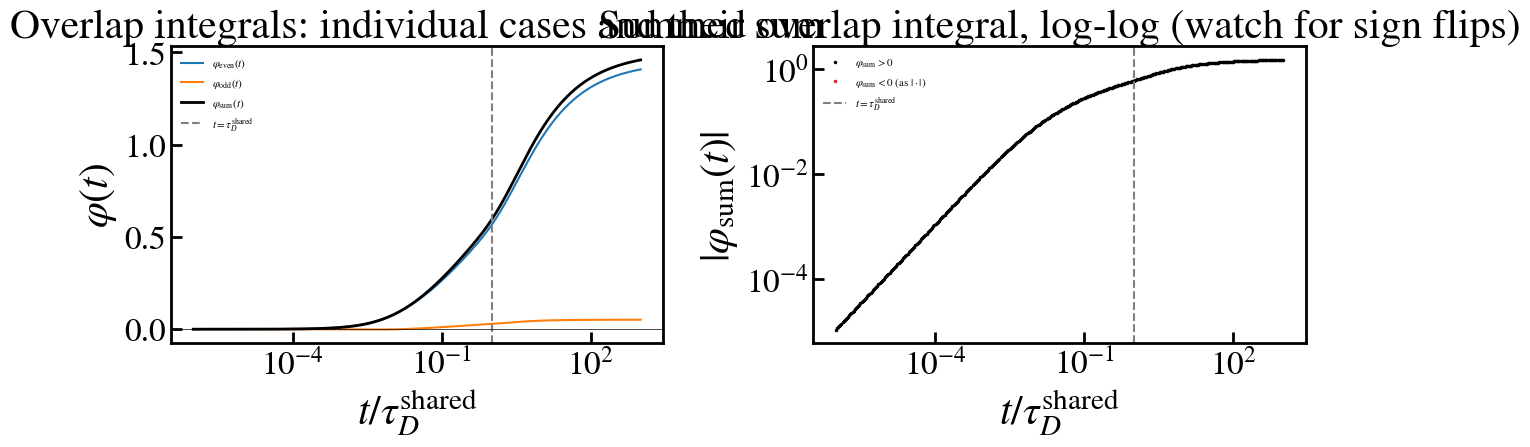

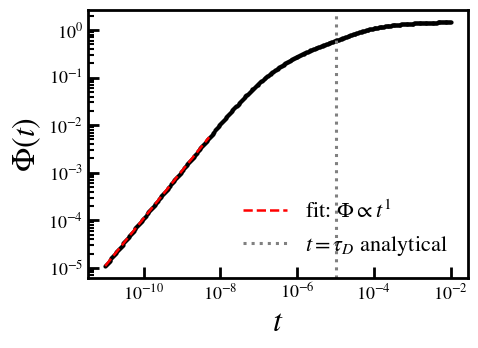

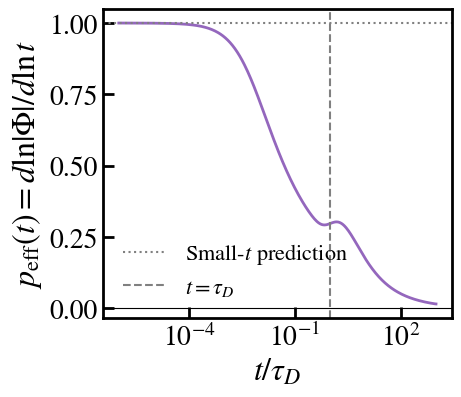

In [ ]:
import numpy as np
from scipy.special import j0
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from scipy.constants import mu_0, h, e
from scipy.constants import physical_constants
from scipy.interpolate import interp1d, CubicSpline
from scipy.special import jv


# ============================================================
# Constants
# ============================================================

phi0 = h / (2 * e)
n=1e-9
um = 1e-6

# ============================================================
# User parameters
# ============================================================

I_target_nA = 6.3
I_target = I_target_nA * 1e-9   # A

b_um = 0.1
b = b_um * um

lam_um = 0.07
lam = lam_um * um

gamma = 0.2236
g = 1.0

mu_B = physical_constants['Bohr magneton'][0]
mu_s = mu_B

# FastHenry cut window
y_min_um = -7.5
y_max_um = -2.5
y_center_um = 0.5 * (y_min_um + y_max_um)

# SC width
W_um = 5.0
W = W_um * um

# Field observation height
Z_um = 0.05
Z_m = Z_um * um

# Monte Carlo / noise settings
sigma_m2 = 5e17
sigma_um2 = sigma_m2 * 1e-12

lam_tilde = lam**2 / (b * W)

K=1
K=-g*mu_s*mu_0*W/(8*np.pi*I_target*1e-9*phi0)
C=K*2*I_target/(np.pi*b*W*(1-gamma*np.sqrt(2*lam_tilde)))


# ----------------------------------------------------------------------
# Parameters -- EDIT THESE to your actual values
# ----------------------------------------------------------------------
Z = Z_um    # depth / decay parameter in f_tilde
b = b_um      # "slab thickness" parameter in f_tilde
W = W_um      # width parameter in J_tilde
#C = 1.0      # constant prefactor in J_tilde
D = 2.25e5     # diffusion coefficient
chi = 1.0    # susceptibility prefactor

# ----------------------------------------------------------------------
# The two f_tilde variants
# ----------------------------------------------------------------------
def f_tilde_even(k, Z=Z, b=b):
    """f_tilde(k) = e^{-Z|k|} (1 - e^{-b|k|}) / |k|, with the k->0 limit = b.
    Real and EVEN in k -> B(x) real and EVEN in x."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk, dtype=complex)  # complex dtype for uniformity with the odd case
    small = absk < 1e-13
    out[~small] = -2*np.pi*np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / absk[~small]
    out[small] = -2*np.pi*b  # analytic k->0 limit
    return out

def f_tilde_odd(k, Z=Z, b=b):
    """f_tilde(k) = -1j * e^{-Z|k|} (1 - e^{-b|k|}) / k  (signed k in denominator).
    Purely imaginary and ODD in k -> B(x) real and ODD in x.
    At k=0 the one-sided limits are +/- i*b (genuine jump); we use the
    principal-value / odd-extension convention: value 0 at k=0."""
    k = np.asarray(k, dtype=float)
    absk = np.abs(k)
    out = np.empty_like(absk, dtype=complex)
    small = absk < 1e-13
    out[~small] = -2*np.pi*1j * np.exp(-Z*absk[~small]) * (1 - np.exp(-b*absk[~small])) / k[~small]
    out[small] = 0.0
    return out

def J_tilde(k, C=C, W=W, N=32):
    """J_tilde(k) = (C W / 2) * J0(k W / 2)  -- real, even in k."""

    alpha=1-2*np.acos(1-lam_tilde)/np.pi
    w=W*lam_tilde
    print(alpha)
    k = np.asarray(k, dtype=float)
    J =(alpha*np.pi*j0(k * W / 2.0))
    for n in range(1, N+1):
        coeff = 2*np.sin(np.pi*n*alpha)/n
        J += coeff*jv(2*n, k*W/2.0)
    den = k**2 + 1/W**2
    a = 1.0 / (lam_tilde * W)
    I = (
        2
        * (
            np.exp(a * w / 2)
            * (
                k * np.sin(k * W / 2)
                + a * np.cos(k * W / 2)
            )
            - (
                k * np.sin(k * (W - w) / 2)
                + a * np.cos(k * (W - w) / 2)
            )
        )
        / (k**2 + a**2)
    )
    J += (1/np.sqrt(2*lam_tilde))*I
    return (C) * J

CASES = {
    'even': dict(f=f_tilde_even, color='tab:blue',   label=r'even $\tilde f$ (real, symmetric $B$)'),
    'odd':  dict(f=f_tilde_odd,  color='tab:orange', label=r'odd $\tilde f$ (imaginary, antisymmetric $B$)'),
}

# ----------------------------------------------------------------------
# Uniform grid setup for FFT (shared by both cases)
# ----------------------------------------------------------------------
N = 2**16
L = 2000*W
dx = L / N
x = (np.arange(N) - N//2) * dx

k = 2*np.pi*np.fft.fftfreq(N, d=dx)

def inverse_transform(Fk):
    """Given F(k) sampled on our fftfreq-based k grid, return F(x) on the x grid."""
    return np.fft.ifft(Fk) / dx

# ----------------------------------------------------------------------
# Build B_tilde(k), B(x), and k_c/tau_D for each case
# ----------------------------------------------------------------------
def find_kc_tauD(Bk_case, k, D):
    """Robust k_c extraction: search the peak of |B_tilde(k)| restricted to
    k>=0 (handles both k=0-peaked and away-from-zero-peaked spectra), with
    an rms-width fallback."""
    idx = np.argsort(k)
    k_sorted = k[idx]
    absB_sorted = np.abs(Bk_case[idx])
    pos = k_sorted >= 0
    k_pos = k_sorted[pos]
    absB_pos = absB_sorted[pos]

    peak = absB_pos.max()
    i_peak = np.argmax(absB_pos)
    target = peak/np.e
    k_c = None
    for i in range(i_peak, len(k_pos)-1):
        if absB_pos[i] >= target >= absB_pos[i+1]:
            k_c = k_pos[i] + (target-absB_pos[i])*(k_pos[i+1]-k_pos[i])/(absB_pos[i+1]-absB_pos[i])
            break
    if k_c is None or k_c <= 0:
        w = absB_pos**2
        k_c = np.sqrt(np.trapezoid(k_pos**2 * w, k_pos) / np.trapezoid(w, k_pos))
    tau_D = 1.0/(D*k_c**2)
    return k_c, tau_D, k_pos[i_peak]

for name, c in CASES.items():
    Bk_case = c['f'](k) * J_tilde(k)
    Bx_case = inverse_transform(Bk_case)
    im_ratio = np.max(np.abs(Bx_case.imag)) / np.max(np.abs(Bx_case.real))
    Bx_case = np.fft.fftshift(Bx_case.real)
    k_c, tau_D, k_peak = find_kc_tauD(Bk_case, k, D)

    c['Bk'] = Bk_case
    c['Bx'] = Bx_case
    c['k_c'] = k_c
    c['tau_D'] = tau_D
    print(f"[{name}] max|Im B(x)|/max|Re B(x)| = {im_ratio:.2e}   "
          f"peak|B_tilde(k)| at k={k_peak:.4f}   k_c={k_c:.4f}   tau_D={tau_D:.4f}")

def m_of_x_t(case, t):
    Bk_case = case['Bk']
    filt = np.exp(-k**2 * D * t)
    diffused = inverse_transform(Bk_case * filt).real
    diffused = np.fft.fftshift(diffused)
    return chi * (case['Bx'] - diffused)

# Use a single shared tau_D (e.g. the max of the two) so both cases are
# animated/plotted on a common, physically meaningful time axis.
tau_D_shared = max(c['tau_D'] for c in CASES.values())
print(f"\nUsing shared tau_D = {tau_D_shared:.4f} (max of the two cases) "
      f"for common time axis in plots/animation.")

# ========================================================================
# ANIMATION: m(x,t) for both cases, side by side in time
# ========================================================================
xmax_plot = 6*W
mask_plot = np.abs(x) < xmax_plot
x_plot = x[mask_plot]

t_anim = np.logspace(-4, 3, 150) * tau_D_shared  # log-spaced frames

fig_anim, ax_anim = plt.subplots(figsize=(8, 5.5))
lines = {}
for name, c in CASES.items():
    (line,) = ax_anim.plot([], [], color=c['color'], lw=2, label=c['label'])
    lines[name] = line
    ax_anim.plot(x_plot, chi*c['Bx'][mask_plot], color=c['color'], lw=1, ls=':', alpha=0.6)
    #ax_anim.plot(X_um, Fx, color="black", lw=1, ls=':', alpha=1)
    #ax_anim.plot(X_um, Fz, color="black", lw=1, ls=':', alpha=1)

# fix y-limits from the envelope of both saturation profiles so the frame
# doesn't rescale during the animation
ymax = max(np.max(np.abs(chi*c['Bx'][mask_plot])) for c in CASES.values())
ax_anim.set_xlim(x_plot.min(), x_plot.max())
ax_anim.set_ylim(-1.3*ymax, 1.3*ymax)
ax_anim.axhline(0, color='k', lw=0.5)
ax_anim.set_xlabel('x')
ax_anim.set_ylabel('m(x,t)')
ax_anim.legend(loc='upper right', fontsize=9)
time_text = ax_anim.text(0.02, 0.95, '', transform=ax_anim.transAxes, fontsize=11,
                          verticalalignment='top')

def init():
    for name in CASES:
        lines[name].set_data([], [])
    time_text.set_text('')
    return list(lines.values()) + [time_text]

def update(frame):
    t = t_anim[frame]
    for name, c in CASES.items():
        mt = m_of_x_t(c, t)
        lines[name].set_data(x_plot, mt[mask_plot])
    time_text.set_text(fr'$t = {t/tau_D_shared:.3g}\,\tau_D^{{\rm shared}}$')
    return list(lines.values()) + [time_text]

anim = animation.FuncAnimation(fig_anim, update, frames=len(t_anim),
                                init_func=init, blit=True, interval=60)
anim.save('m_xt_animation.gif', writer='pillow', fps=18, dpi=110)
plt.close(fig_anim)
print("Saved animation to m_xt_animation.gif")

# ========================================================================
# Overlap integrals for each case, and their SUM
# ========================================================================
mask_W = np.abs(x) <= W/2.0
x_W = x[mask_W]

def phi_of_t(case, t):
    mt = m_of_x_t(case, t)
    B_W = case['Bx'][mask_W]
    return np.trapezoid(mt[mask_W] * B_W, x_W)

t_phi = np.logspace(-6, 3, 400) * tau_D_shared

phi_vals = {}
for name, c in CASES.items():
    phi_vals[name] = np.array([phi_of_t(c, t) for t in t_phi])

phi_sum = sum(phi_vals.values())  # combined overlap integral used for fits from here on

# ---- Plot: individual overlaps + their sum ----
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))

ax = axes3[0]
for name, c in CASES.items():
    ax.semilogx(t_phi/tau_D_shared, phi_vals[name], color=c['color'], label=fr'$\varphi_{{\rm {name}}}(t)$')
ax.semilogx(t_phi/tau_D_shared, phi_sum, color='k', lw=2, label=r'$\varphi_{\rm sum}(t)$')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D^{\rm shared}$')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$t/\tau_D^{\rm shared}$')
ax.set_ylabel(r'$\varphi(t)$')
ax.set_title('Overlap integrals: individual cases and their sum')
ax.legend(fontsize=8)

ax = axes3[1]
pos = phi_sum > 0
neg = phi_sum < 0
ax.loglog(t_phi[pos]/tau_D_shared, phi_sum[pos], '.', color='k', ms=3, label=r'$\varphi_{\rm sum}>0$')
ax.loglog(t_phi[neg]/tau_D_shared, -phi_sum[neg], '.', color='tab:red', ms=3, label=r'$\varphi_{\rm sum}<0$ (as $|\cdot|$)')
ax.axvline(1.0, color='gray', ls='--', label=r'$t=\tau_D^{\rm shared}$')
ax.set_xlabel(r'$t/\tau_D^{\rm shared}$')
ax.set_ylabel(r'$|\varphi_{\rm sum}(t)|$')
ax.set_title('Summed overlap integral, log-log (watch for sign flips)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('phi_t_combined.png', dpi=150)
print("Saved plot to phi_t_combined.png")

# ========================================================================
# Power-law fit (early time) and effective exponent, on phi_sum
# ========================================================================
n_fit = 40
t_fit = t_phi[:n_fit]
phi_fit_data = phi_sum[:n_fit]
sign_fit_data = np.sign(phi_fit_data)

if not np.all(sign_fit_data == sign_fit_data[0]):
    print(f"\nWARNING: sign of phi_sum(t) changes within the first {n_fit} points "
          f"-- fitting |phi_sum(t)|; interpret the exponent with care.")

logt = np.log(t_fit)
logphi = np.log(np.abs(phi_fit_data))
p, logA = np.polyfit(logt, logphi, 1)
A = np.exp(logA)

print(f"\nEarly-time power-law fit of phi_sum over first {n_fit} points "
      f"(t/tau_D in [{t_fit[0]/tau_D_shared:.2e}, {t_fit[-1]/tau_D_shared:.2e}]):")
print(f"  |phi_sum(t)| ~ A * t^p")
print(f"  p (slope) = {p:.4f}   (expect ~1 from linear-in-t theory)")
print(f"  A         = {A:.4e}")
print(f"  sign(phi_sum) over fit window: "
      f"{'constant = ' + str(int(sign_fit_data[0])) if np.all(sign_fit_data==sign_fit_data[0]) else 'CHANGES'}")

fig4, ax4 = plt.subplots(figsize=(5.3, 4))

pos_all = phi_sum > 0
neg_all = phi_sum < 0

ax4.loglog(
    t_phi[pos_all],#/tau_D_shared,
    phi_sum[pos_all],
    '.',
    color='k',
    ms=4,
    #label=r'$\varphi_{\rm sum}>0$'
)

# ax4.loglog(
#     t_phi[neg_all],#/tau_D_shared,
#     -phi_sum[neg_all],
#     '.',
#     color='tab:red',
#     ms=4,
#     label=r'$\varphi_{\rm sum}<0$ (as $|\cdot|$)'
# )

# ax4.loglog(
#     t_fit,#/tau_D_shared,
#     np.abs(phi_fit_data),
#     'o',
#     color='tab:green',
#     ms=7,
#     mfc='none',
#     label=f'points used in fit (n={n_fit})'
# )

t_line = np.array([t_fit[0], t_phi[n_fit*3]])

ax4.loglog(
    t_line,#/tau_D_shared,
    A*t_line**p,
    'r--',
    lw=1.8,
    label=fr'fit: $\Phi\propto t^{{{p:.0f}}}$'
)

ax4.axvline(
    tau_D_shared,
    color='gray',
    ls=':',
    lw=2.2,
    label=r'$t=\tau_D$ analytical'
)

ax4.set_xlabel(r'$t$', fontsize=23)
ax4.set_ylabel(r'$\Phi(t)$', fontsize=23)
#ax4.set_title('Early-time power-law fit', fontsize=17)

# Increase tick-label size
ax4.tick_params(axis='both', which='major', labelsize=13)
ax4.tick_params(axis='both', which='minor', labelsize=11)

# Larger legend
ax4.legend(fontsize=16)

plt.tight_layout()
plt.savefig('phi_t_combined_fit.png', dpi=300, bbox_inches='tight')
plt.savefig('phi_t_combined_fit.pdf')
print("Saved plot to phi_t_combined_fit.png")


# ---- effective exponent p_eff(t) = d ln|phi_sum| / d ln t ----

valid = phi_sum != 0

lt = np.log(t_phi[valid])
lphi = np.log(np.abs(phi_sum[valid]))
t_valid = t_phi[valid]
sign_valid = np.sign(phi_sum[valid])

p_eff = np.gradient(lphi, lt)

fig5, ax5 = plt.subplots(figsize=(5, 4.5))

sign_change = np.where(np.diff(sign_valid) != 0)[0]

ax5.semilogx(
    t_valid/tau_D_shared,
    p_eff,
    color='tab:purple',
    lw=2
)

for idx in sign_change:
    ax5.axvline(
        t_valid[idx]/tau_D_shared,
        color='tab:red',
        ls='-',
        alpha=0.3,
        lw=1.5,
        label='sign change in $\varphi_{\rm sum}(t)$'
        if idx == sign_change[0] else None
    )

ax5.axhline(
    1.0,
    color='gray',
    ls=':',
    lw=1.5,
    label=r'Small-$t$ prediction'
)

ax5.axhline(
    0.0,
    color='k',
    lw=0.8
)

ax5.axvline(
    1.0,
    color='gray',
    ls='--',
    lw=1.5,
    label=r'$t=\tau_D$'
)

ax5.set_xlabel(r'$t/\tau_D$', fontsize=23)
ax5.set_ylabel(
    r'$p_{\rm eff}(t) = d\ln|\Phi|/d\ln t$',
    fontsize=23
)
# ax5.set_title(
#     'Effective (local) power-law exponent',
#     fontsize=17
# )

# Increase tick-label size
ax5.tick_params(axis='both', which='major', labelsize=20)
ax5.tick_params(axis='both', which='minor', labelsize=18)

# Larger legend
ax5.legend(fontsize=16)

plt.tight_layout()
plt.savefig('p_eff_t_combined.png', dpi=300, bbox_inches='tight')
plt.savefig('p_analytical.pdf')
print("Saved plot to p_eff_t_combined.png")

In [ ]:
np.save(
    'p_analytical', p_eff
)
np.save(
    't_analytical', t_valid
)

# Analytical and numerical comparison after getting the data from the other notebook

Common time domain: [1.083227e-10, 4.000000e-04]


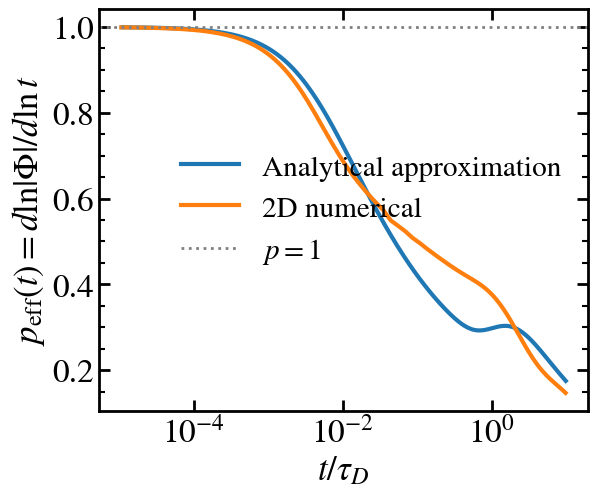

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load data
# ============================================================

p_analytical = np.load("p_analytical.npy")
t_analytical = np.load("t_analytical.npy")

p_2d = np.load("p_2d.npy")
t_2d = np.load("t_2d.npy")


# ============================================================
# Find common time domain
# ============================================================

t_min = max(t_analytical.min(), t_2d.min())
t_max = min(t_analytical.max(), t_2d.max())

print(f"Common time domain: [{t_min:.6e}, {t_max:.6e}]")

# Masks
mask_analytical = (
    (t_analytical >= t_min) &
    (t_analytical <= t_max)
)

mask_2d = (
    (t_2d >= t_min) &
    (t_2d <= t_max)
)

t_a = t_analytical[mask_analytical]
p_a = p_analytical[mask_analytical]

t_n = t_2d[mask_2d]
p_n = p_2d[mask_2d]


# ============================================================
# Plot style
# ============================================================

plt.rcParams.update({
    "font.size": 24,
    "axes.labelsize": 30,
    "axes.titlesize": 30,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 21,

    "axes.linewidth": 2.0,

    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,

    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "legend.frameon": False,

    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 5.5))

ax.semilogx(
    t_a[t_a < 9.9e-5] / tau_D_shared,
    p_a[t_a < 9.9e-5],
    '-',
    lw=3,
    label='Analytical approximation'
)

ax.semilogx(
    t_n[t_n < 9.9e-5] / tau_D_shared,
    p_n[t_n < 9.9e-5],
    '-',
    lw=3,
    label='2D numerical'
)

ax.axhline(
    1.0,
    color='gray',
    ls=':',
    lw=2,
    label=r'$p=1$'
)


# ============================================================
# Labels
# ============================================================

ax.set_xlabel(
    r'$t/\tau_D$',
    fontsize=25
)

ax.set_ylabel(
    r'$p_{\rm eff}(t)=d\ln|\Phi|/d\ln t$',
    fontsize=25
)

# ax.set_title(
#     'Effective exponent: analytical vs 2D numerical',
#     fontsize=30,
#     pad=12
# )


# ============================================================
# Ticks
# ============================================================

ax.tick_params(
    axis='both',
    which='major',
    labelsize=24,
    direction='in',
    length=8,
    width=2,
    top=True,
    right=True
)

ax.tick_params(
    axis='both',
    which='minor',
    labelsize=20,
    direction='in',
    length=4,
    width=1.5,
    top=True,
    right=True
)

ax.minorticks_on()


# ============================================================
# Legend
# ============================================================

ax.legend(
    fontsize=21,
    frameon=False
)


# ============================================================
# Save
# ============================================================

plt.tight_layout()

plt.savefig(
    'p_eff_analytical_vs_2d.png',
    dpi=300,
    bbox_inches='tight'
)
plt.savefig("final dif exp comp.pdf")
plt.show()

# Check of numerical method with analytical result of diffusion of an initial delta

<>:244: SyntaxWarning: invalid escape sequence '\d'
<>:244: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1242/2203924604.py:244: SyntaxWarning: invalid escape sequence '\d'
  plt.title("1D diffusion of a Gaussian approximation to $\delta(x-x_0)$")


dx = 1.000000e-08 m
sigma = 1.000000e-08 m
dt = 2.500000e-07 s
D dt / dx² = 0.250

Normalization:
t =   0.10 ms   mass = 1.0000000000
t =   0.20 ms   mass = 1.0000000000
t =   0.50 ms   mass = 1.0000000000
t =   1.00 ms   mass = 1.0000000000
t =   2.00 ms   mass = 1.0000000000
t =   5.00 ms   mass = 1.0000000000


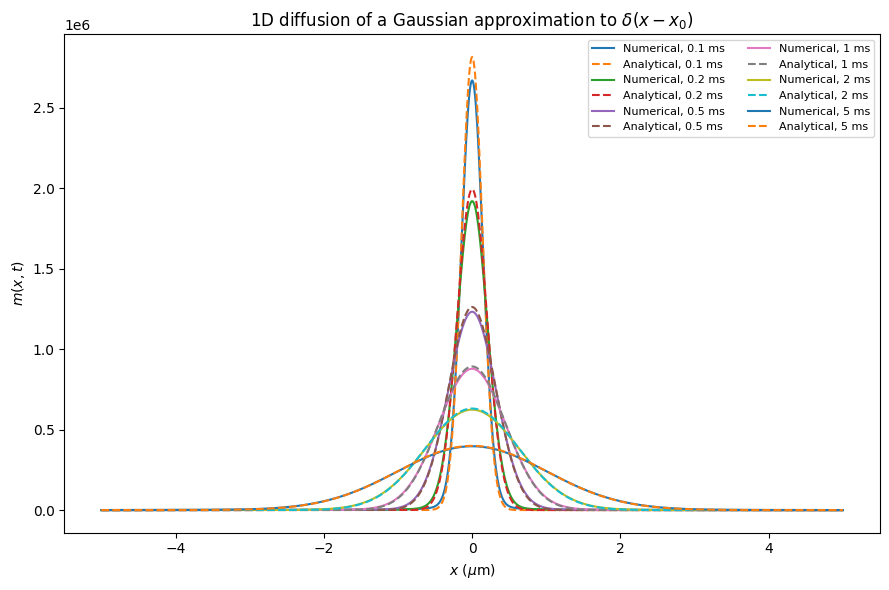


Errors:
t =   0.10 ms   max error = 1.452634e+05   relative error = 5.162312e-02
t =   0.20 ms   max error = 7.336266e+04   relative error = 3.682453e-02
t =   0.50 ms   max error = 2.927444e+04   relative error = 2.321644e-02
t =   1.00 ms   max error = 1.432742e+04   relative error = 1.606502e-02
t =   2.00 ms   max error = 6.990202e+03   relative error = 1.108317e-02
t =   5.00 ms   max error = 2.641526e+03   relative error = 6.621654e-03


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1D Laplacian with Neumann boundary conditions
# ============================================================

def laplacian1d_neumann(f, dx):

    lap = np.zeros_like(f)

    # Interior
    lap[1:-1] = (
        f[2:] - 2.0*f[1:-1] + f[:-2]
    ) / dx**2

    # Left boundary
    lap[0] = (
        f[1] - f[0]
    ) / dx**2

    # Right boundary
    lap[-1] = (
        f[-2] - f[-1]
    ) / dx**2

    return lap


# ============================================================
# FTCS diffusion step
# ============================================================

def step_ftcs_1d(m, D, dx, dt):

    lap_m = laplacian1d_neumann(m, dx)

    return m + D * dt * lap_m


# ============================================================
# Gaussian approximation to Dirac delta
# ============================================================

def gaussian_delta(x, x0, sigma):

    delta = (
        np.exp(
            -(x - x0)**2 / (2.0*sigma**2)
        )
        /
        (np.sqrt(2.0*np.pi) * sigma)
    )

    # Normalize numerically on the finite grid
    delta /= np.sum(delta) * (x[1] - x[0])

    return delta


# ============================================================
# Analytical solution
# ============================================================

def analytical_solution(x, t, x0, sigma, D):

    sigma_t = np.sqrt(
        sigma**2 + 2.0*D*t
    )

    return (
        np.exp(
            -(x - x0)**2 / (2.0*sigma_t**2)
        )
        /
        (np.sqrt(2.0*np.pi) * sigma_t)
    )


# ============================================================
# Parameters
# ============================================================

L = 10e-6
Nx = 1001

x = np.linspace(-L/2, L/2, Nx)
dx = x[1] - x[0]

D = 1e-10                 # m²/s
x0 = 0.0                  # initial position

# Width of Gaussian approximation to delta
sigma = 1.0 * dx


def lorentzian_delta(x, x0, epsilon):
    """
    Continuous Lorentzian approximation to Dirac delta:

        delta_epsilon(x-x0)
        = (1/pi) * epsilon /
          ((x-x0)^2 + epsilon^2)

    """

    delta = (
        epsilon
        / (
            np.pi * (
                (x - x0)**2 + epsilon**2
            )
        )
    )

    # Normalize on the finite numerical domain
    delta /= np.sum(delta) * (x[1] - x[0])

    return delta


# ============================================================
# Initial condition
# ============================================================

m = gaussian_delta(
    x,
    x0,
    sigma
)

m = lorentzian_delta(
    x,
    x0,
    sigma
)


# ============================================================
# FTCS stability
# ============================================================

r = 0.25

dt = r * dx**2 / D

print(f"dx = {dx:.6e} m")
print(f"sigma = {sigma:.6e} m")
print(f"dt = {dt:.6e} s")
print(f"D dt / dx² = {D*dt/dx**2:.3f}")


# ============================================================
# Times
# ============================================================

times = [
    #0.0,
    0.1e-3,
    0.2e-3,
    0.5e-3,
    1.0e-3,
    2.0e-3,
    5.0e-3
]


# ============================================================
# Numerical evolution
# ============================================================

solutions = []

t = 0.0

for target_time in times:

    while t < target_time:

        m = step_ftcs_1d(
            m,
            D,
            dx,
            dt
        )

        t += dt

    solutions.append(m.copy())


# ============================================================
# Numerical diagnostics
# ============================================================

print("\nNormalization:")

for ti, mi in zip(times, solutions):

    mass = np.sum(mi) * dx

    print(
        f"t = {ti*1e3:6.2f} ms   "
        f"mass = {mass:.10f}"
    )


# ============================================================
# Numerical vs analytical
# ============================================================

plt.figure(figsize=(9, 6))

for ti, mi in zip(times, solutions):

    # Numerical
    plt.plot(
        x * 1e6,
        mi,
        label=f"Numerical, {ti*1e3:g} ms"
    )

    # Analytical
    m_exact = analytical_solution(
        x,
        ti,
        x0,
        sigma,
        D
    )

    plt.plot(
        x * 1e6,
        m_exact,
        "--",
        linewidth=1.5,
        label=f"Analytical, {ti*1e3:g} ms"
    )


plt.xlabel(r"$x$ ($\mu$m)")
plt.ylabel(r"$m(x,t)$")
plt.title("1D diffusion of a Gaussian approximation to $\delta(x-x_0)$")

plt.legend(
    fontsize=8,
    ncol=2
)

plt.tight_layout()
plt.show()


# ============================================================
# Error analysis
# ============================================================

print("\nErrors:")

for ti, mi in zip(times, solutions):

    m_exact = analytical_solution(
        x,
        ti,
        x0,
        sigma,
        D
    )

    error = np.max(
        np.abs(mi - m_exact)
    )

    relative_error = error / np.max(m_exact)

    print(
        f"t = {ti*1e3:6.2f} ms   "
        f"max error = {error:.6e}   "
        f"relative error = {relative_error:.6e}"
    )